# Recommandation de films et succès au box-office — notebook principal

**Projet Data Visualisation, sujet n°4.** Une plateforme de streaming veut décider quels films produire, et à quels spectateurs les proposer. Ce notebook rassemble les deux volets de modélisation du projet.

| Partie | Question | Tables lues dans `data/processed/` |
|---|---|---|
| **A — Succès au box-office** | peut-on estimer, avant la production, la probabilité qu'un film soit rentable ? | `succes_dataset.parquet`, `movies.parquet` |
| **B — Recommandation** | à quels spectateurs proposer quels films ? | `ratings.parquet`, `movielens_movies.parquet` |

**Exécution.** Le notebook se lance de haut en bas, depuis le dossier `notebooks/`, après l'installation décrite dans le README. Il ne demande ni téléchargement ni clé API : toutes les tables lues sont dans le dépôt. Compter environ 10 minutes et 7 Go de mémoire vive disponible : la partie B charge 32 millions de notes. Les deux parties sont indépendantes, et chacune garde sa propre numérotation de sections.

**Sources** : MovieLens `ml-32m`, API TMDB, jeux de données non commerciaux IMDb, indice des prix à la consommation américain (FRED).

> **Et la qualité des données ?**
>
> L'audit des données fait l'objet d'un notebook séparé, `01_qualite_donnees.ipynb` : les trois sources, l'entonnoir de sélection des films, les valeurs manquantes, les doublons, les valeurs aberrantes, les contradictions entre sources, l'inflation et les biais.
>
> **Il n'est pas repris dans ce notebook**, parce qu'il lit les sources brutes et les tables intermédiaires du pipeline : les fichiers MovieLens d'origine, le cache TMDB, les extraits IMDb et le référentiel commun des films. Ces fichiers pèsent environ 2 Go et ne sont pas dans le dépôt : sans eux, ses cellules ne peuvent pas s'exécuter.
>
> Il est livré **déjà exécuté** : ses résultats et ses figures se lisent sans rien lancer. Pour le rejouer, il faut d'abord reconstituer les sources brutes, comme l'indique le README (« Reconstituer les sources brutes », environ 1 h 30 avec une clé TMDB gratuite).

# Partie A — Prédire la rentabilité d'un film

**Problématique** : une plateforme de streaming veut choisir son prochain film à produire. Peut-on estimer, **avant la production**, la probabilité qu'il soit rentable ?

**Cible** : `is_hit`, le film rapporte-t-il au moins **2,5 fois son budget** en dollars constants 2023 ? Seuil issu du métier : les salles gardent environ la moitié des recettes et le marketing n'est pas compris dans le budget.

**Contrainte** : aucune variable connue après la sortie. Elle est vérifiée par une expérience de contrôle en section 8.

**Organisation du code** : les traitements sont dans `src/boxoffice/`, ce notebook contient surtout des appels et des commentaires.

| Module | Rôle |
|---|---|
| `features/success.py` | construction du jeu d'entraînement à partir des tables nettoyées |
| `models/entrainement.py` | préparation, banc d'essai, réglage, évaluation, seuils, simulation |
| `models/succes.py` | enregistrement du modèle et de sa carte d'identité |
| `viz/technique.py` | figures techniques (Matplotlib, Seaborn) |
| `viz/metier.py` | figures interactives (Plotly) |

| | Section | Question |
|---|---|---|
| 1 | Données et cible | que cherche-t-on à prédire ? |
| 2 | Analyse exploratoire | quelles variables semblent liées au succès ? |
| 3 | Protocole d'évaluation | comment mesurer honnêtement ? |
| 4 | Réduction de dimension | faut-il transformer les variables ? |
| 5 | Présélection et choix | quelle famille de modèles ? |
| 6 | Réglage et diagnostics | surapprentissage, volume de données |
| 7 | Évaluation et seuil de décision | que vaut le modèle, où fixer la frontière ? |
| 8 | Contrôle méthodologique | le modèle a-t-il triché ? |
| 9 | Interprétabilité | quelles caractéristiques prédisent le succès ? |
| 10 | Enregistrement | conserver le modèle validé |
| 11 | Améliorations | qu'est-ce qui a fait progresser le modèle ? |
| 12 | Apport du modèle | une règle simple aurait-elle suffi ? |

## Résumé exécutif

**Question** : peut-on estimer, avant la production, la probabilité qu'un film soit rentable ?

**Réponse** : oui, avec une fiabilité utile mais imparfaite. Sur des films jamais vus par le modèle, **72 % de ceux qu'il recommande sont rentables, contre 35 % dans le catalogue**.

| | Le point clé | Le chiffre | Section |
|---|---|---|---|
| 1 | Cible et contrainte : rentabilité, sans aucune variable postérieure à la sortie | 9 268 films, 34 variables | 1 |
| 2 | Quatre familles comparées avant tout réglage ; l'écart est dans le bruit | AUC 0,745 contre 0,737 | 5 et 6 |
| 3 | Performance sur un test temporel, films sortis à partir de 2018 | **AUC 0,749** | 7 |
| 4 | Là où il se trompe : zone d'abstention et effet COVID | 72 % / 40 % / 15 % par zone | 7 |
| 5 | Ce qui prédit le succès | saga (le public connaît déjà l'univers), budget, notoriété | 9 |
| 6 | Ce que le modèle apporte face à la règle « toutes les sagas » | 72 % de films rentables contre 60 % | 12 |

**Honnêteté du modèle** : en ajoutant les recettes aux variables, l'AUC monterait à 0,999. Notre score est celui d'un modèle qui n'a pas le droit de regarder la réponse.

**Limites assumées** : biais de sélection (seuls les films au budget public), box-office brut et non bénéfice, et une fermeture des salles en 2020-2021 qu'aucun modèle ne pouvait anticiper.


In [1]:
from boxoffice.features import success
from boxoffice.models import entrainement, succes as persistance
from boxoffice.viz import metier, technique

technique.appliquer_style()
metier.activer_affichage()

data = success.charger()
variables = success.colonnes_variables(data)
jeu = entrainement.preparer(data, variables)

print(f"{len(data):,} films | {len(variables)} variables | {100 * data['is_hit'].mean():.1f} % de films rentables")
data[["title", "year", "log_budget", "is_franchise", "is_hit"]].head(3)

9,268 films | 34 variables | 38.6 % de films rentables


,title,year,log_budget,is_franchise,is_hit
0,Toy Story,1995,17.909646,1,True
1,Jumanji,1995,18.682836,1,True
2,Grumpier Old Men,1995,17.727325,1,True


## 1. Données et cible

Le jeu vient du pipeline du projet : collecte MovieLens, TMDB et IMDb, nettoyage, jointure des trois sources, puis construction des variables. Le détail du nettoyage est dans le notebook de qualité des données.

Les 34 variables sont toutes **connues avant la production** : budget, genres, durée, mois de sortie, franchise ou saga (le public connaît déjà l'univers), studio, langue, pays, classification d'âge, et la notoriété du réalisateur et des têtes d'affiche calculée **uniquement sur leurs films antérieurs**.

### Pourquoi une classification, et pas une régression du montant ?

Deux formulations étaient possibles : prédire **si** un film sera rentable, ou prédire **combien** il rapportera. Nous avons mesuré les deux avant de choisir.

In [2]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np, pandas as pd

roi = data["log_roi"].astype(float)
regression = HistGradientBoostingRegressor(categorical_features=jeu["indices_categoriels"], random_state=42)
regression.fit(jeu["X"].loc[jeu["i_train"]], roi[jeu["i_train"]])
prediction = regression.predict(jeu["X"].loc[jeu["i_test"]])

pd.DataFrame([
    {"formulation": "régression : prédire le ROI", "mesure": "R2", "valeur": round(r2_score(roi[jeu["i_test"]], prediction), 3),
     "lecture": f"facteur d'erreur {np.exp(mean_absolute_error(roi[jeu['i_test']], prediction)):.1f} sur le ROI prédit"},
    {"formulation": "classification : prédire la rentabilité", "mesure": "AUC", "valeur": 0.749,
     "lecture": "72 % des films recommandés sont rentables"},
]).set_index("formulation")

,mesure,valeur,lecture
formulation,,,
régression : prédire le ROI,R2,0.143,facteur d'erreur 3.4 sur le ROI prédit
classification : prédire la rentabilité,AUC,0.749,72 % des films recommandés sont rentables


**La régression ne permet pas de décider.** Un R² de 0,14 et un facteur d'erreur de 3,4 signifient qu'un ROI annoncé à 3 peut valoir 1 comme 10. Le box-office est trop imprévisible en montant.

**La classification, elle, produit une décision exploitable** : une probabilité de rentabilité, comparable à un seuil.

**Décision : on prédit `is_hit`**, le film rapporte-t-il au moins 2,5 fois son budget.

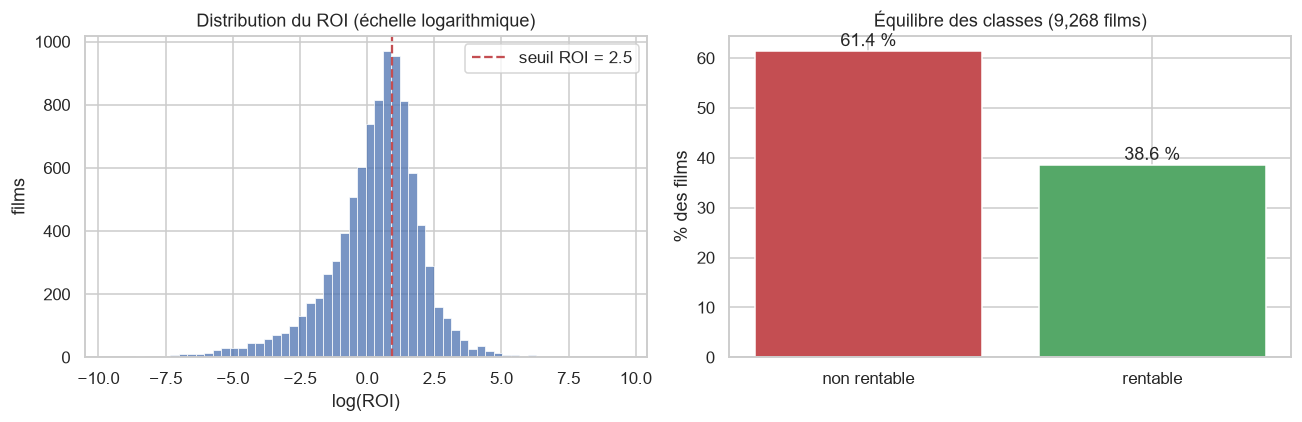

In [3]:
technique.distribution_cible(data);

Un histogramme montre la forme d'une distribution : c'est lui qui révèle que le ROI n'est lisible qu'en échelle logarithmique. Deux barres suffisent à côté pour juger l'équilibre entre les classes.

Le ROI s'étale de 0,00007 à 12 890 : en échelle logarithmique la distribution devient symétrique. Le seuil de 2,5 partage la population en **38,6 % de films rentables contre 61,4 %**, deux classes assez équilibrées pour que les métriques restent lisibles.

### Comment le ROI est calculé

```
roi = recettes / budget        (les deux en dollars constants 2023)
```

C'est un **multiple**, pas un pourcentage : un ROI de 2,5 signifie « le film rapporte 2,5 fois sa mise ». Au sens financier strict, `(recettes - budget) / budget`, cela correspond à **+150 %**. Les deux conventions se déduisent l'une de l'autre : `ROI financier = multiple - 1`.

### Et l'inflation ?

**Tous les montants sont convertis en dollars de 2023**, avec l'indice des prix à la consommation américain (série CPIAUCSL de la Réserve fédérale de Saint-Louis) : chaque budget et chaque recette est multiplié par le coefficient de l'année de sortie du film. Le détail est dans le notebook de qualité des données, section 8.

**Sur le ROI, cette correction ne change rien** : budget et recettes datent de la même année, ils sont multipliés par le même coefficient, qui s'annule dans la division.

| Film de 1995 | Budget | Recettes | ROI |
|---|---|---|---|
| en dollars de 1995 | 30 M$ | 90 M$ | 90 / 30 = **3** |
| en dollars de 2023 (un dollar de 1995 en vaut environ deux) | 60 M$ | 180 M$ | 180 / 60 = **3** |

**Sur le budget utilisé comme variable, elle est indispensable** : sans elle, 30 M$ en 1985 et 30 M$ en 2020 auraient la même valeur pour le modèle, alors que le premier est une grosse production et le second un film moyen.

| Élément | Corrigé de l'inflation | Raison |
|---|---|---|
| ROI, la cible | sans effet | le coefficient s'annule dans la division |
| Budget, variable du modèle | oui, dollars 2023 | comparer des films d'époques différentes |

**Limite.** On suppose que budget et recettes sont exprimés dans les dollars de la même année. En réalité le budget est dépensé un à deux ans avant la sortie, et certaines recettes viennent de ressorties : l'écart est faible, mais il existe.

### Pourquoi le seuil est fixé à 2,5, et pas à 1

**Ce que contiennent nos deux montants.**

| Montant | Ce qu'il contient | Ce qu'il ne contient pas | D'où on le sait |
|---|---|---|---|
| `revenue` : recettes | le box-office brut, mondial si disponible, sinon américain : le total des billets vendus en salles | la part gardée par les salles n'est pas déduite ; ni streaming, ni vidéo, ni télévision | règles de saisie de TMDB ([Movie Bible](https://www.themoviedb.org/bible/movie?language=en-US)) |
| `budget` : budget | le coût de production du film | la promotion et la distribution, payées à part | convention du secteur ([Film budgeting](https://en.wikipedia.org/wiki/Film_budgeting), Wikipedia) ; TMDB ne le précise pas, mais nos valeurs sont celles des budgets de production publiés (Avatar 237 M$, Inception 160 M$) |

**Les deux hypothèses du calcul.**

| Hypothèse | Valeur retenue | Ordre de grandeur du secteur | Source |
|---|---|---|---|
| Part des recettes qui revient au studio | 50 % | 50 % aux États-Unis, 40 % à l'international, 25 % en Chine | [Blockbuster movie economics 101](https://brandstofans.substack.com/p/blockbuster-movie-economics-101-and) (W. Harrison, 2025) ; [List of biggest box-office bombs](https://en.wikipedia.org/wiki/List_of_biggest_box-office_bombs) (Wikipedia) |
| Coût de la promotion | 25 % du budget | environ 50 % du budget | [Film promotion](https://en.wikipedia.org/wiki/Film_promotion) (Wikipedia) |

Les deux valeurs retenues sont les plus favorables au studio : le seuil obtenu est un minimum.

**Le calcul, pour un film à 100 M$ de budget.**

| ROI | Billets vendus<br>= ROI × budget | Part du studio<br>= 50 % des billets | À rembourser<br>= production + promotion | Résultat | Lecture |
|---|---|---|---|---|---|
| 0 | 0 | 0 | 125 M$ | **-125 M$** | aucune recette |
| 1 | 100 M$ | 50 M$ | 125 M$ | **-75 M$** | les billets égalent le budget, le studio n'en reçoit que la moitié |
| 2 | 200 M$ | 100 M$ | 125 M$ | **-25 M$** | la production est remboursée, pas la promotion |
| 2,5 | 250 M$ | 125 M$ | 125 M$ | **0** | point mort : tout est remboursé |

La part du studio dépend du ROI ; ce qu'il doit rembourser n'en dépend pas, puisque production et promotion sont payées avant la sortie. D'où la formule générale :

```
ROI au point mort = (1 + promotion / budget) / part des recettes qui revient au studio = (1 + 0,25) / 0,5 = 2,5
```

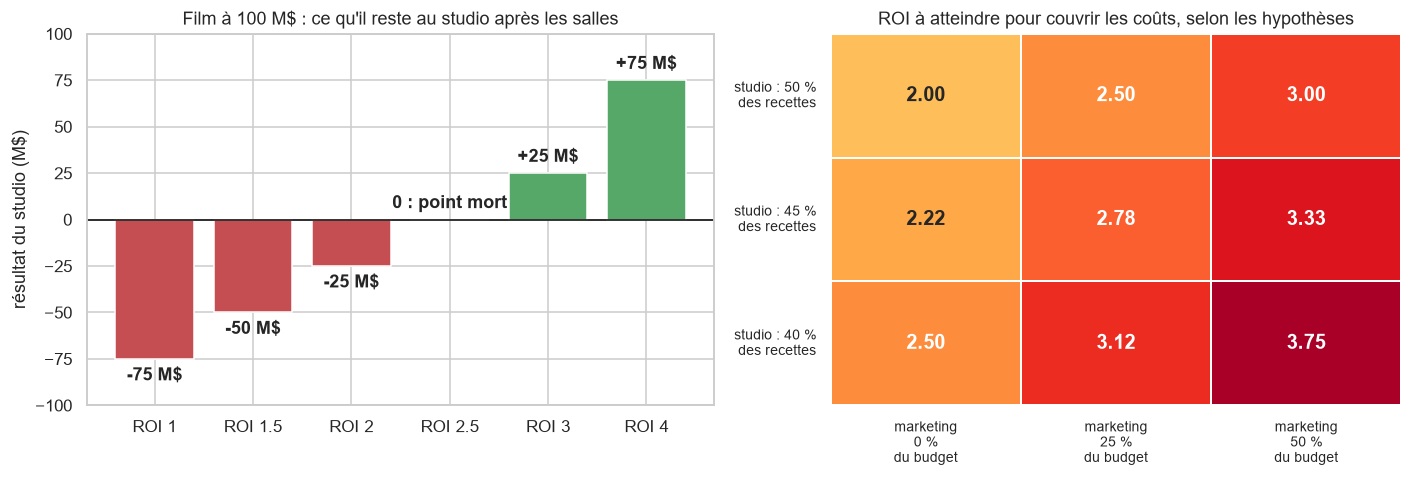

In [4]:
resultat_studio, grille = success.resultat_studio(), success.grille_point_mort()
technique.seuil_rentabilite(resultat_studio, grille);

Des barres de part et d'autre de zéro, pour voir d'un coup d'œil de quel côté du point mort tombe chaque niveau de ROI. Une grille colorée pour l'analyse de sensibilité : deux hypothèses croisées, une valeur par case.

**Aucune hypothèse réaliste ne ramène le point mort sous 2.** La grille va de 2,0 à 3,75, et la valeur 2,0 suppose un film sorti sans aucune promotion. Avec la promotion à la moitié du budget, le point mort serait à 3.

**Où se situent nos 9 268 films.**

| Tranche de ROI | Part des films | Lecture |
|---|---|---|
| moins de 1 | 34,9 % | les billets ne couvrent pas le budget |
| de 1 à 2 | 18,8 % | la production n'est pas remboursée |
| de 2 à 2,5 | 7,7 % | il manque la promotion |
| 2,5 et plus | 38,6 % | rentables : la classe « succès » |

Avec un seuil à 1, les 26,5 % de films situés entre 1 et 2,5 seraient étiquetés « rentables » alors que le studio y perd de l'argent en salles.

**Limite.** Les deux hypothèses sont des ordres de grandeur du secteur, pas la comptabilité de chaque film : les contrats entre studios et salles ne sont pas publics. C'est pourquoi le seuil est mis à l'épreuve ci-dessous.

### Le choix du seuil change-t-il les conclusions ?

Un seuil défini hors des données mérite vérification. On réentraîne le modèle avec cinq définitions du succès, dont le seuil à 1, et on regarde ce qu'il apprend et quels films il met en tête.

,part de succès %,AUC test,3 premières variables,ROI médian des 120 films les mieux classés,dont films à perte %
seuil ROI,,,,,
1.0,65.09,0.72,"is_franchise, log_budget, pays",3.68,8.33
1.5,54.66,0.75,"is_franchise, log_budget, pays",4.23,5.00
2.0,46.27,0.75,"is_franchise, log_budget, pays",4.64,6.67
2.5,38.60,0.75,"is_franchise, log_budget, director_taux_hits_a...",4.61,9.17
3.0,32.43,0.75,"is_franchise, log_budget, cast_taux_hits_avant",4.61,10.00


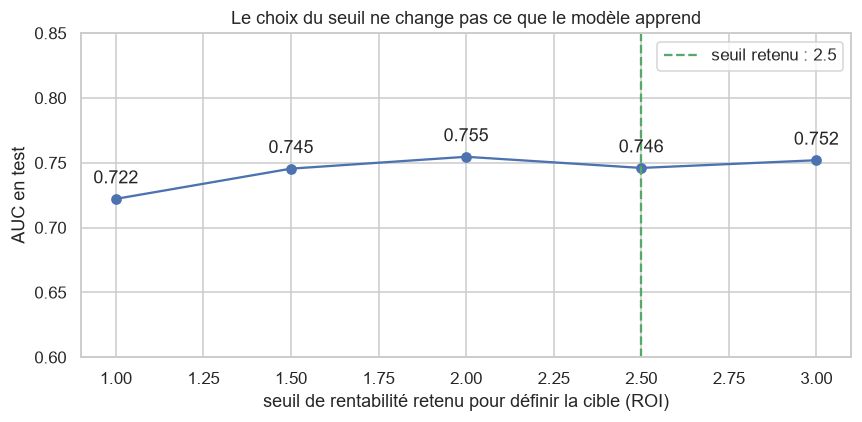

In [5]:
sensibilite = entrainement.sensibilite_seuil(data, jeu)
technique.sensibilite_seuil(sensibilite)
sensibilite.round(2)

Une courbe, parce que le seuil est une grandeur continue et que l'on cherche une tendance : ici, la ligne reste presque plate.

**Le seuil change peu ce que le modèle apprend et ce qu'il recommande.**

| Ce que l'on compare | Seuil à 1 | Seuil à 2,5 |
|---|---|---|
| AUC sur le test | 0,72 | 0,75 |
| Deux premières variables | saga, budget | saga, budget |
| ROI médian des 120 films les mieux classés | 3,7 | 4,6 |
| Films à perte parmi eux | 8 % | 9 % |

Avec n'importe lequel des cinq seuils, la saga (le public connaît déjà l'univers) et le budget arrivent en tête, et les films que le modèle classe premiers ont un ROI médian supérieur à 3,5. Même entraîné avec un seuil à 1, il fait remonter des films qui dépassent largement 2,5.

Le seuil déplace donc surtout la frontière entre les deux classes. Nous retenons **celui qui correspond à un film réellement rentable pour le studio**, et non celui qui donnerait les chiffres les plus flatteurs : à 1, le taux de succès passerait de 39 % à 65 %.

## 2. Analyse exploratoire

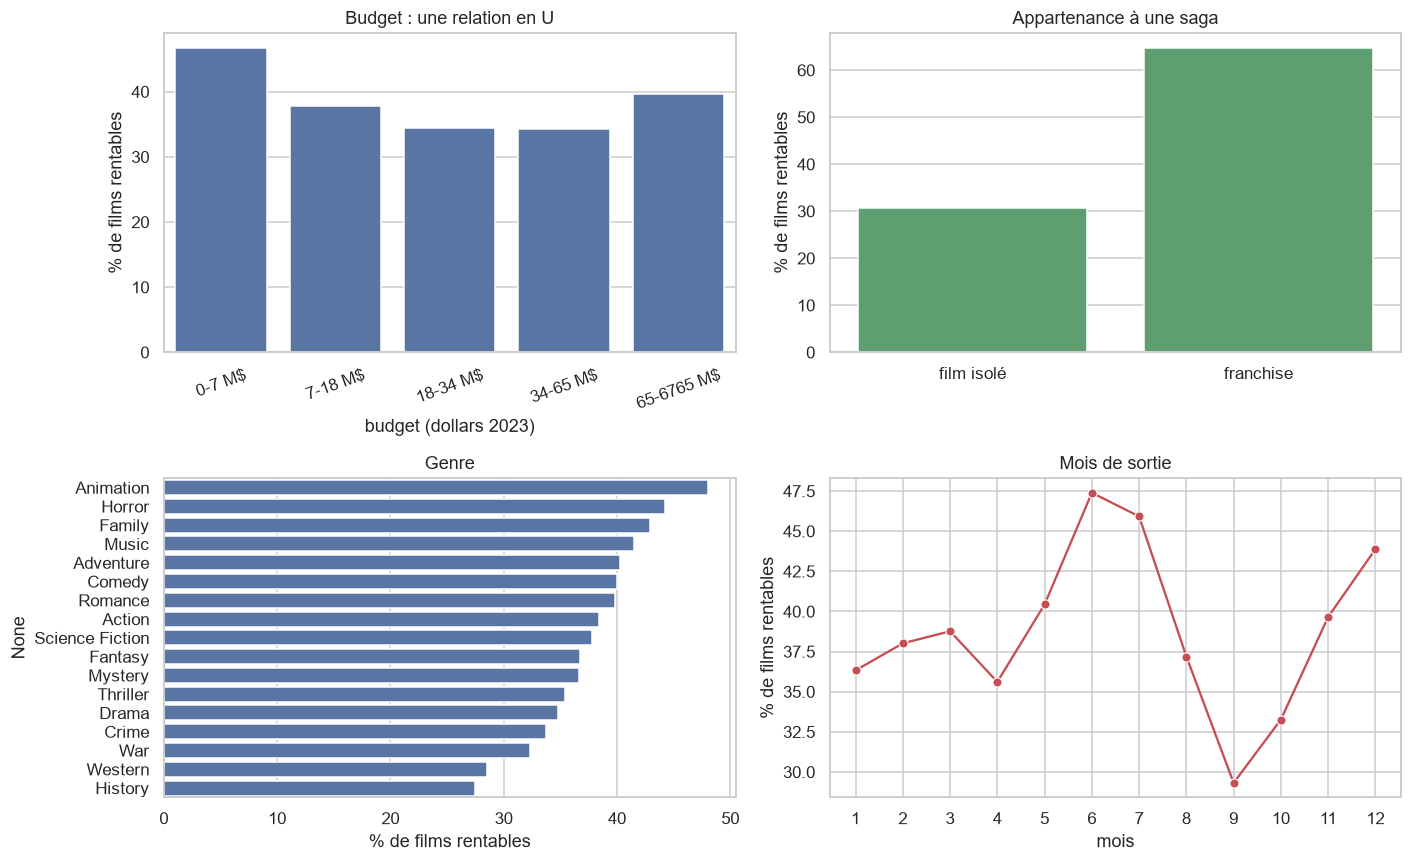

In [6]:
technique.exploration(data);

Des barres pour comparer un taux entre catégories (tranches de budget, saga, genres). Une ligne pour les mois, parce qu'ils se suivent dans l'ordre et que l'on cherche une saisonnalité.

**La relation budget-succès n'est pas monotone** : petits budgets et très gros budgets réussissent mieux que les budgets intermédiaires. À partir du budget seul, un modèle linéaire ne peut pas représenter cette forme en U, un modèle à base d'arbres le peut : c'est une première raison de comparer plusieurs familles. La section 9 montre d'où vient la remontée des gros budgets.

Pour explorer film par film, le même nuage en version interactive.

In [7]:
metier.nuage_films(data)

Un nuage de points, parce qu'il croise deux grandeurs continues film par film. Les deux axes sont logarithmiques car budgets et ROI s'étalent sur plusieurs ordres de grandeur ; la version interactive donne le titre au survol.

## 3. Protocole d'évaluation

| | Rôle | Mise en œuvre |
|---|---|---|
| **Découpage temporel** | mesurer la performance sur des films jamais vus | entraînement avant 2018, test à partir de 2018 |
| **Validation croisée stratifiée** | comparer et régler les modèles | 5 blocs sur le seul jeu d'entraînement |

Le test n'est utilisé qu'une fois, à la fin. Un découpage aléatoire aurait donné de meilleurs chiffres, mais apprendre sur des films de 2020 pour en prédire de 2005 n'a aucun sens métier.

### Les métriques, et comment les lire

| Métrique | Ce qu'elle mesure | Quand elle est bonne |
|---|---|---|
| **AUC** | la capacité à **ordonner** les films du moins au plus prometteur, quel que soit le seuil de décision | 0,5 = hasard ; 0,65 à 0,75 = signal réel sur un phénomène incertain ; au-delà de 0,9 sur du box-office, suspecter une fuite de données |
| **accuracy** | la part de films correctement classés | **à comparer au plancher** : 65 % ici en prédisant « non rentable » partout. Seule, elle ne veut rien dire |
| **precision** | quand le modèle annonce un succès, à quelle fréquence il a raison | à comparer au taux de base de 35 % : l'écart au-dessus mesure l'apport réel |
| **recall** | la part des succès réels que le modèle retrouve | dépend du coût métier : une valeur basse est acceptable si se tromper coûte plus cher que rater |
| **F1** | le compromis entre precision et recall | pertinent quand les deux erreurs coûtent autant, ce qui n'est pas le cas pour un studio |
| **score de Brier** | la **fiabilité des probabilités** annoncées, pas seulement du classement | plus bas est meilleur ; se compare à 0,227, valeur d'un modèle qui annoncerait toujours le taux de base |
| **log loss** | la même idée, en pénalisant plus fortement les erreurs confiantes | sert ici à déclencher l'arrêt anticipé, pas à juger le modèle |

**Aucune de ces métriques ne se juge dans l'absolu** : chacune se compare à un plancher, et c'est l'écart à ce plancher qui mesure l'apport du modèle. L'AUC guide la sélection car elle ne dépend d'aucun seuil ; la **precision** intéresse le studio, puisqu'elle mesure l'argent engagé dans des films annoncés rentables qui ne l'étaient pas.

In [8]:
print(f"entraînement : {len(jeu['i_train']):,} films | test : {len(jeu['i_test']):,} films")
print(f"films rentables : {100 * jeu['y'][jeu['i_train']].mean():.1f} % en entraînement, "
      f"{100 * jeu['y'][jeu['i_test']].mean():.1f} % en test")
print(f"repères : tout prédire « non rentable » donne accuracy = {1 - jeu['y'][jeu['i_test']].mean():.3f} et AUC = 0.500")

entraînement : 8,285 films | test : 983 films
films rentables : 39.0 % en entraînement, 35.0 % en test
repères : tout prédire « non rentable » donne accuracy = 0.650 et AUC = 0.500


## 4. Réduction de dimension : l'ACP est-elle utile ?

Question à trancher **avant** l'entraînement, et sur des mesures plutôt que par principe.

composantes nécessaires pour 95 % de variance : 29 sur 51


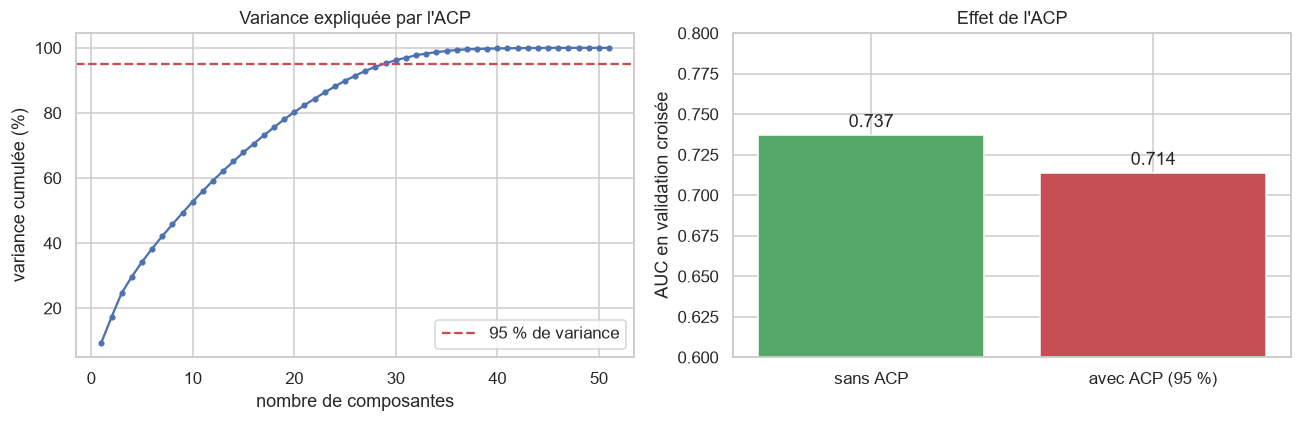

In [9]:
resultat_acp = entrainement.comparer_acp(jeu)
technique.acp(resultat_acp)
print(f"composantes nécessaires pour 95 % de variance : "
      f"{resultat_acp['composantes_95']} sur {resultat_acp['composantes_totales']}")

La courbe de variance cumulée est la lecture standard d'une ACP : on y lit combien de composantes il faut garder. Deux barres suffisent pour la comparaison avant / après.

**Décision : pas d'ACP.** Elle dégrade l'AUC, il faut presque autant de composantes que de variables pour conserver 95 % de la variance, et une composante principale n'a aucun sens métier alors que le livrable attendu est la liste des caractéristiques du succès.

## 5. Présélection : quelle famille de modèles ?

Le problème est une classification binaire sur un tableau de 34 variables de natures différentes (montants, indicatrices, catégories), avec des valeurs manquantes. On compare quatre familles, avant tout réglage.

### Pourquoi ces quatre familles

Elles forment une **échelle de complexité** : chacune corrige la limite de la précédente. Si un échelon n'apporte rien, la complexité ajoutée ne se justifie pas.

| Famille | Comment elle décide | Ce qu'elle a de particulier | Sa limite sur nos données |
|---|---|---|---|
| **Régression logistique** | une somme pondérée des variables, transformée en probabilité | un coefficient par variable : le sens et la force de chaque effet se lisent directement | chaque effet va dans un seul sens, et aucune interaction n'existe si on ne la crée pas à la main ; exige imputation et mise à l'échelle |
| **Arbre de décision** (profondeur 6) | une suite de questions oui / non sur les variables | capte les seuils et les interactions (« saga **et** gros budget »), sans mise à l'échelle | instable : quelques films en plus ou en moins changent l'arbre ; 64 feuilles au plus, donc 64 probabilités possibles |
| **Forêt aléatoire** (300 arbres) | 300 arbres profonds, chacun entraîné sur un tirage aléatoire de films et de variables, puis moyenne | la moyenne annule les erreurs propres à chaque arbre : elle **réduit la variance** | les arbres s'ignorent entre eux : une erreur commune à tous n'est jamais corrigée |
| **Gradient boosting** | des petits arbres construits **en série**, chacun entraîné sur les erreurs laissées par les précédents | il **réduit le biais** pas à pas ; la version par histogrammes traite nativement valeurs manquantes et catégories | plus de réglages, et un surapprentissage possible si l'on ajoute trop d'arbres : voir l'arrêt anticipé en section 6 |

**Le rôle de chacune dans la comparaison** : la régression logistique est la référence qu'un modèle plus complexe doit battre pour mériter sa place ; l'arbre seul mesure ce que vaut la brique de base ; la forêt et le boosting sont les deux façons opposées de combiner des arbres, en parallèle ou en série.

**Familles non testées**, par choix a priori et non sur mesure : les k plus proches voisins et les SVM reposent sur des distances, mal définies quand on mélange montants, catégories et valeurs manquantes ; un réseau de neurones demanderait plus de réglages et serait moins lisible, sur un tableau de 8 285 lignes où les ensembles d'arbres sont la référence habituelle.

,AUC,AUC std,F1,accuracy,fit time (s)
modèle,,,,,
gradient boosting,0.745,0.013,0.572,0.704,0.459
régression logistique,0.737,0.011,0.551,0.701,0.084
forêt aléatoire,0.737,0.010,0.543,0.700,0.949
arbre de décision,0.681,0.014,0.507,0.676,0.069


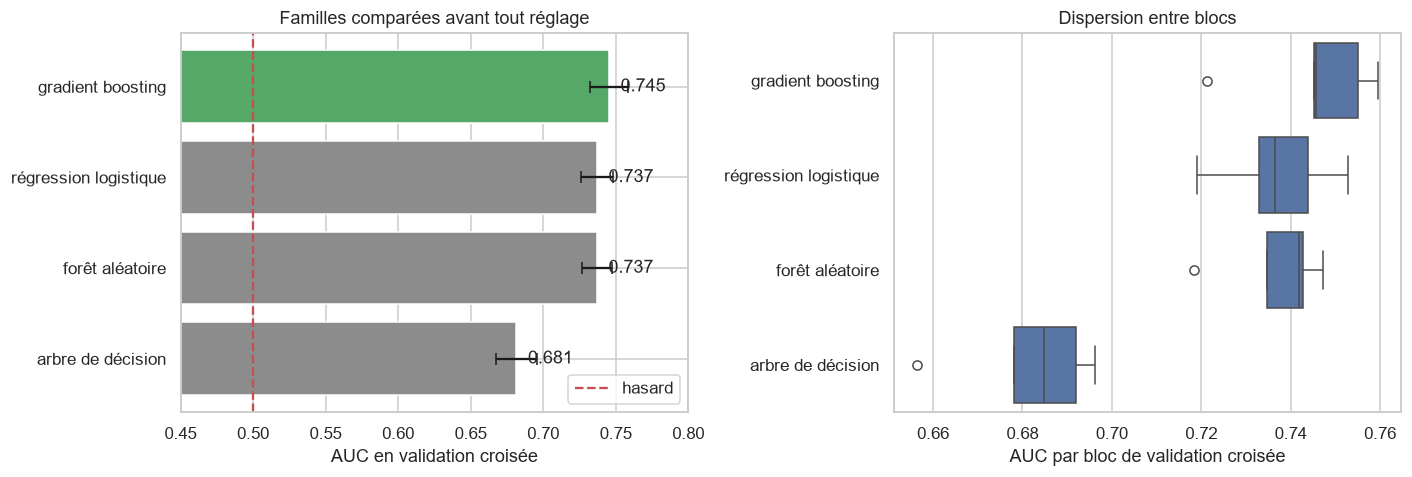

In [10]:
banc, scores_par_bloc = entrainement.banc_essai(jeu)
technique.banc_essai(banc, scores_par_bloc)
banc.round(3)

Des barres horizontales pour classer les modèles, avec leur marge d'erreur. Des boîtes à moustaches à côté pour montrer la dispersion entre les cinq blocs, que la moyenne cache.

**Décision : un seul modèle, le gradient boosting.** La régression logistique reste ce qu'elle est dans le banc d'essai : la référence à battre.

Le gradient boosting arrive en tête, mais l'écart avec la régression logistique est plus petit que l'écart-type entre blocs : ils se valent statistiquement. Le score ne suffit donc pas à trancher. L'arbre seul est nettement derrière : combiner des arbres est ce qui apporte le gain.

### Ce que le gradient boosting a de particulier, mesuré sur nos données

Puisque l'AUC ne départage pas les deux premiers, on regarde deux propriétés concrètes de nos données : la forme en U du budget vue en section 2, et les valeurs manquantes. Les prédictions sont obtenues en validation croisée, sur des films que chaque modèle n'a pas vus.

films d'entraînement avec au moins une valeur manquante : 44.5 %
variables concernées : director_taux_hits_avant 36 %, cast_taux_hits_avant 14 %, age_min 11 %
écart moyen au taux observé, par tranche de budget : régression logistique 1.5 pt, arbre de décision 1.6 pt, forêt aléatoire 2.0 pt, gradient boosting 0.9 pt
AUC avec le budget comme seule variable : régression logistique 0.530, gradient boosting 0.553


,films complets,films avec valeur manquante,écart
modèle,,,
régression logistique,0.743,0.728,-0.015
arbre de décision,0.684,0.681,-0.003
forêt aléatoire,0.740,0.733,-0.007
gradient boosting,0.746,0.743,-0.003


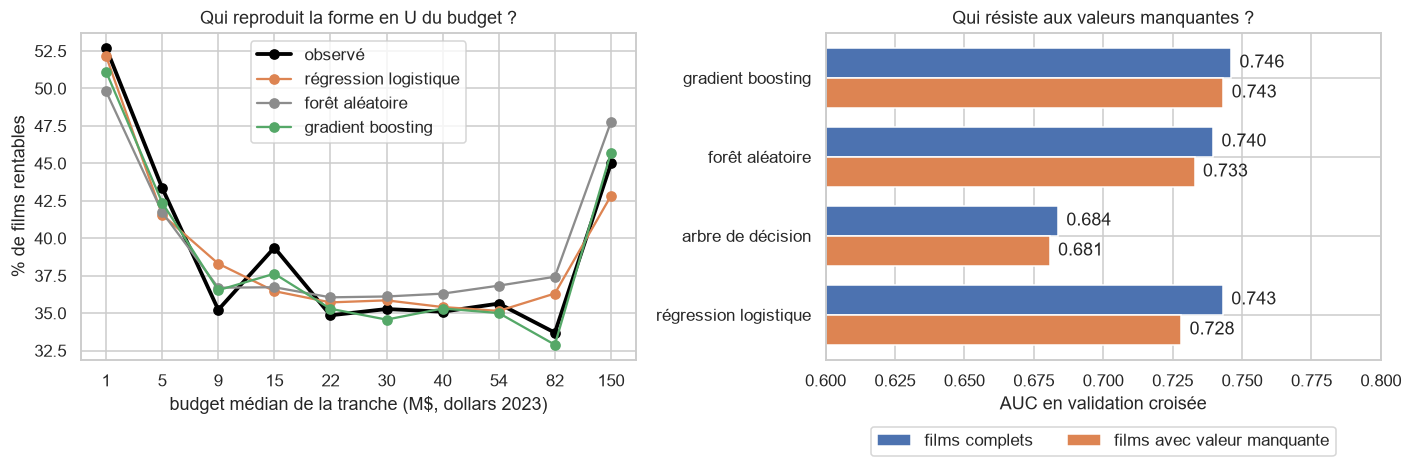

In [11]:
profil = entrainement.particularites(jeu)
technique.particularites(profil)

ecart = profil["budget"].drop(columns="observé").sub(profil["budget"]["observé"], axis=0).abs().mean() * 100
print(f"films d'entraînement avec au moins une valeur manquante : {100 * profil['part_incomplets']:.1f} %")
print("variables concernées : " + ", ".join(f"{nom} {100 * taux:.0f} %" for nom, taux in profil["taux_manquants"].items()))
print("écart moyen au taux observé, par tranche de budget : " + ", ".join(f"{nom} {valeur:.1f} pt" for nom, valeur in ecart.items()))
print("AUC avec le budget comme seule variable : " + ", ".join(f"{nom} {valeur:.3f}" for nom, valeur in profil["budget_seul"].items()))
profil["manquants"].round(3)

Des courbes superposées pour comparer la forme prédite à la forme observée le long du budget. Des barres groupées pour comparer deux situations, modèle par modèle.

**Comment lire les quatre lignes affichées.**

| Ligne | Ce qu'elle dit |
|---|---|
| Films avec au moins une valeur manquante | la part des films où une information n'existe pas : près d'un sur deux |
| Variables concernées | lesquelles, et pour quelle part des films |
| Écart moyen au taux observé | pour chaque tranche de budget, la différence entre le taux de succès prédit et le taux réel ; plus l'écart est petit, mieux le modèle suit la réalité |
| AUC avec le budget comme seule variable | ce que vaut chaque modèle quand il ne dispose que du budget : le gradient boosting en tire davantage |

**Le budget.** Le gradient boosting est celui qui suit le taux observé au plus près : 0,9 point d'écart en moyenne par tranche, contre 1,5 pour la régression logistique et 2,0 pour la forêt. La différence se voit sur les gros budgets : entre 82 et 150 M$, le taux réel passe de 34 % à 45 %, le boosting de 33 % à 46 %, la régression logistique de 36 % à 43 % seulement. La régression logistique retrouve tout de même l'allure générale, grâce aux autres variables : avec le budget seul, elle tombe à une AUC de 0,530 contre 0,553 pour le boosting.

**Les valeurs manquantes.** Elles ne viennent pas d'un nettoyage incomplet : les valeurs fausses ont été retirées dans le notebook de qualité des données. Celles qui restent sont des informations qui **n'existent pas**, et qu'il serait trompeur d'inventer.

| Variable | Films concernés | Pourquoi elle est absente |
|---|---|---|
| Taux de succès passé du réalisateur | 36 % | premier film, ou aucun film antérieur dont le budget et les recettes sont connus |
| Taux de succès passé des têtes d'affiche | 14 % | même raison, pour les trois premiers acteurs |
| Âge minimum conseillé | 11 % | pas de classification française ni américaine dans TMDB |

Au total, 44,5 % des films d'entraînement ont au moins une de ces variables absente. Pour la régression logistique, il faut remplacer ce vide par la médiane, ce qui déguise un débutant en réalisateur moyen : elle perd 0,015 d'AUC sur ces films. Le gradient boosting apprend à chaque découpage de quel côté envoyer les films sans valeur : « pas d'historique » devient une information, et il ne perd que 0,003.

**Ce qu'il a donc de spécial, pour ce projet précisément :**

| Propriété | Pourquoi elle compte ici |
|---|---|
| Arbres en série, chacun corrigeant les erreurs des précédents | reproduit les effets non linéaires sans qu'on ait à les décrire à la main |
| Valeurs manquantes gérées nativement | près d'un film sur deux est concerné, et l'absence d'historique a un sens métier |
| Catégories traitées sans encodage | saison, pays, langue et studio restent quatre variables lisibles |
| Variables regroupées en 255 tranches (histogrammes) | 0,4 s d'entraînement, deux fois moins que la forêt : le réglage de la section 6 reste rapide |

**Ce qu'il n'a pas** : un coefficient lisible par variable. L'explication se fait donc sur le modèle lui-même, en section 9 : importance par permutation pour le poids de chaque variable, valeurs SHAP pour le sens de l'effet.

Ces écarts restent modestes, ce qui est cohérent avec le banc d'essai : le choix repose sur l'adéquation aux données, pas sur une victoire nette au score.

## 6. Réglage et diagnostics d'entraînement

In [12]:
recherche = entrainement.regler(jeu)
modele = recherche.best_estimator_
print(f"AUC en validation croisée : {recherche.best_score_:.3f} "
      f"(réglages par défaut : {banc.loc['gradient boosting', 'AUC']:.3f})")
recherche.best_params_

AUC en validation croisée : 0.746 (réglages par défaut : 0.745)


{'min_samples_leaf': 10,
 'max_leaf_nodes': 15,
 'max_iter': 200,
 'learning_rate': 0.03,
 'l2_regularization': 10.0}

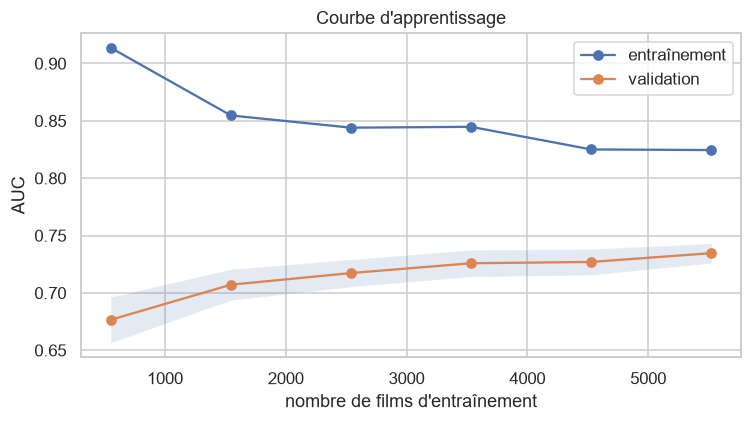

In [13]:
technique.apprentissage(entrainement.courbe_apprentissage(modele, jeu));

Deux courbes, entraînement et validation, en fonction du nombre de films : on lit l'écart entre elles et l'endroit où la validation plafonne.

log loss finale — entraînement 0.422 | validation 0.559


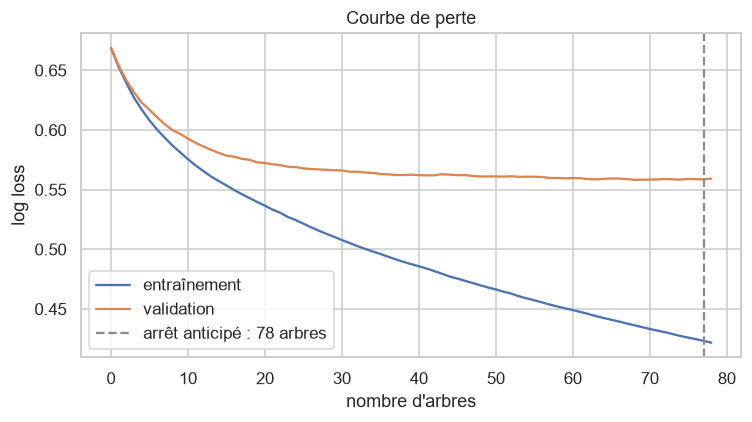

In [14]:
suivi = entrainement.suivi_perte(jeu)
technique.perte(suivi)
print(f"log loss finale — entraînement {-suivi.train_score_[-1]:.3f} | validation {-suivi.validation_score_[-1]:.3f}")

La perte suivie arbre après arbre : le moment où la courbe de validation cesse de baisser indique où arrêter l'entraînement.

**Le réglage n'apporte qu'un gain marginal** : la limite vient de l'information disponible, pas du modèle.

**La courbe d'apprentissage plafonne** vers 3 000 films : davantage de données n'apporterait presque rien, de nouvelles variables si.

**La courbe de perte** montre un surapprentissage contenu par l'arrêt anticipé. Pour un ensemble d'arbres, le nombre d'arbres joue le rôle des époques d'un réseau de neurones.

## 7. Évaluation finale et seuil de décision

Le test temporel n'est utilisé qu'ici.

AUC 0.749 | score de Brier 0.191


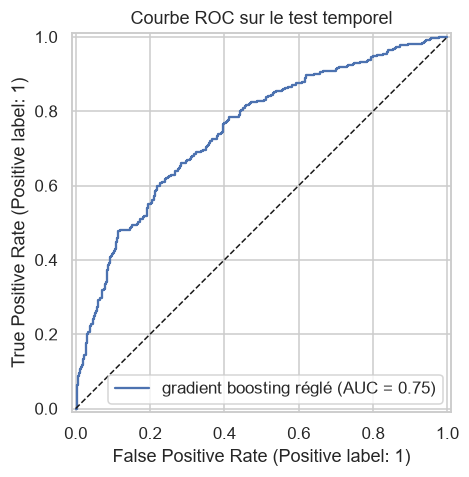

In [15]:
probabilites = entrainement.predire(modele, jeu)
technique.roc(jeu["y"][jeu["i_test"]], probabilites)
mesures = entrainement.evaluer(jeu, probabilites)
print(f"AUC {mesures['AUC']:.3f} | score de Brier {mesures['Brier']:.3f}")

La courbe ROC montre la performance à tous les seuils de décision à la fois, et l'aire sous la courbe est l'AUC. La diagonale représente le hasard.

L'AUC en test est du même ordre qu'en validation croisée, alors que le test contient les années COVID : le modèle généralise à une période qu'il n'a jamais vue.

**Reste à fixer la frontière de décision.** Le seuil de 0,5 n'est qu'un choix par défaut : pour un studio, un faux positif coûte un film financé à perte, un faux négatif une occasion manquée.

,films recommandés,vrais positifs,faux positifs,succès manqués,precision,recall
seuil,,,,,,
0.3,623,289,334,55,0.464,0.840
0.4,456,238,218,106,0.522,0.692
0.5,331,196,135,148,0.592,0.570
0.6,217,148,69,196,0.682,0.430
0.7,120,87,33,257,0.725,0.253
0.8,34,30,4,314,0.882,0.087


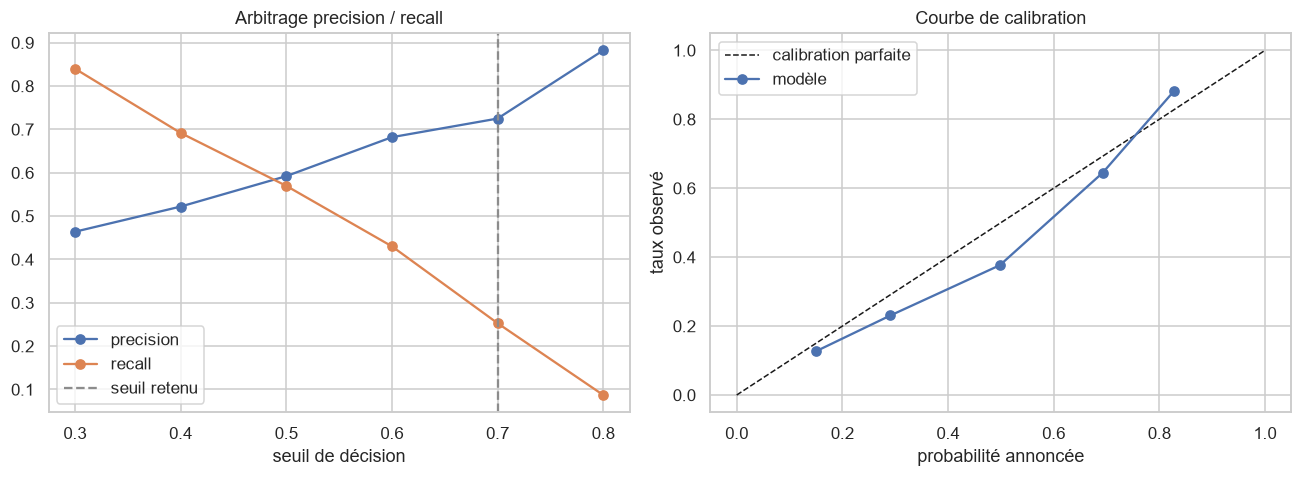

In [16]:
arbitrage = entrainement.arbitrage_seuils(jeu, probabilites)
calibration = entrainement.calibration(jeu, probabilites)
technique.seuils_et_calibration(arbitrage, calibration, entrainement.SEUIL_RECOMMANDATION)
arbitrage.round(3)

Deux courbes qui se croisent rendent l'arbitrage visible : quand la precision monte, le recall descend. La courbe de calibration compare la probabilité annoncée au taux réel : sur la diagonale, le modèle dit vrai.

In [17]:
diagnostic = entrainement.diagnostic_erreurs(data, jeu, probabilites)
entrainement.causes_faux_positifs(diagnostic)

,films
cause,
"ROI entre 2 et 2,5 : seuil manqué de peu",26
sorti en 2020 ou 2021 (fermeture des salles),49
budget TMDB supérieur à 400 M$ (valeur suspecte),2
ROI inférieur à 1 : véritable échec,65


,films recommandés,precision
période,,
2018-2019,166,0.687
2020-2021 (COVID),79,0.380
2022-2023,86,0.605


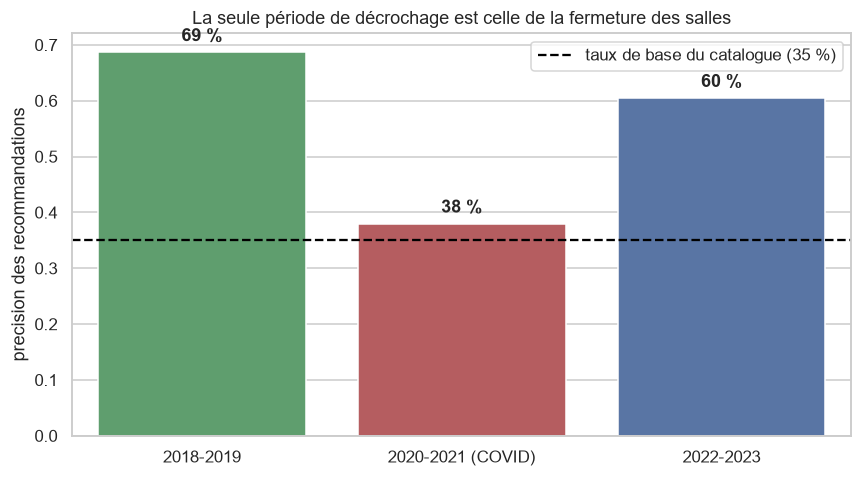

In [18]:
periodes = entrainement.precision_par_periode(diagnostic)
technique.precision_par_periode(periodes, jeu["y"][jeu["i_test"]].mean())
periodes.round(3)

Des barres, parce que l'on compare trois périodes distinctes, avec le taux de base en pointillé comme repère.

**Une partie des faux positifs s'explique.** Au seuil de 0,5, sur 135 faux positifs, 49 sont sortis pendant la fermeture des salles et 26 ont manqué le seuil de rentabilité de peu ; 65 sont de véritables échecs, avec un ROI inférieur à 1. Au même seuil, la precision atteint 69 % en 2018-2019 et tombe à 38 % en 2020-2021.

### Décision : seuil à 0,7, avec une zone d'abstention

| Probabilité | Décision |
|---|---|
| au-dessus de 0,7 | recommander |
| entre 0,3 et 0,7 | examiner au cas par cas |
| sous 0,3 | écarter |

Le graphique suivant montre pourquoi cette zone intermédiaire est nécessaire : chaque barre est un groupe de films, coloré selon ce qu'ils ont réellement rapporté.

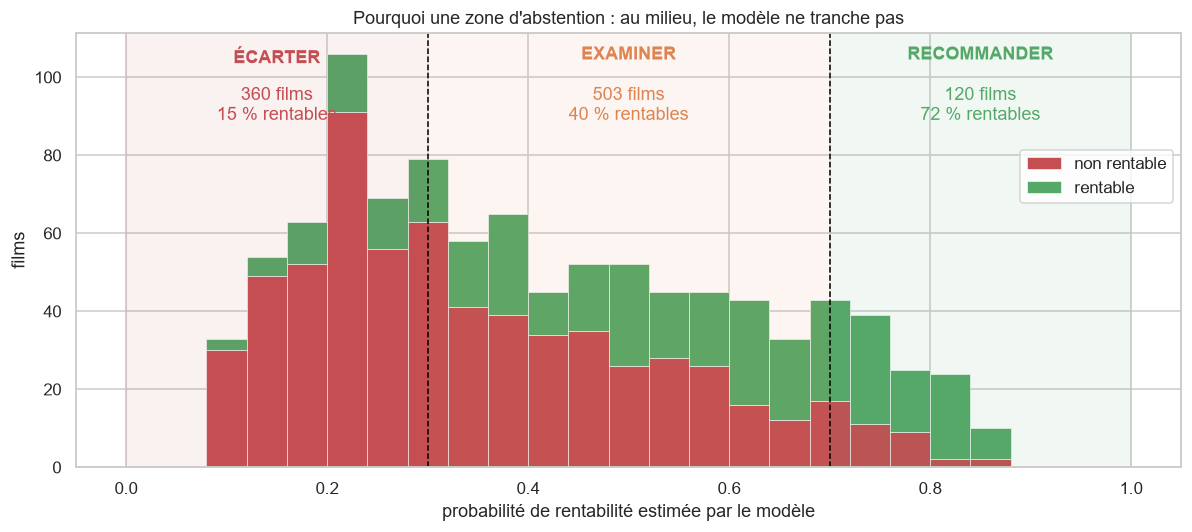

In [19]:
technique.zones_decision(probabilites, jeu["y"][jeu["i_test"]].values,
                         entrainement.SEUIL_REJET, entrainement.SEUIL_RECOMMANDATION);

Un histogramme empilé montre à la fois combien de films reçoivent chaque probabilité et la part de films rentables parmi eux. C'est le mélange des couleurs au centre qui justifie la zone d'abstention.

**Les deux extrémités sont tranchées, le milieu ne l'est pas.** À gauche, l'immense majorité des films sont rouges : les écarter fait perdre peu de succès. À droite, le vert domine : recommander y est fiable.

**Au centre, rouge et vert se mélangent.** Dans cette zone, 40 % des films sont rentables, à peine plus que les 35 % du catalogue : y forcer une décision n'apporterait presque rien par rapport à un choix sans modèle. L'abstention n'est pas un aveu de faiblesse : c'est la lecture honnête de ce que le modèle sait et de ce qu'il ne sait pas.

C'est aussi ce qui explique le nombre apparemment élevé de succès manqués : **la plupart ne sont pas rejetés, ils sont en attente d'examen humain.**

,films,taux_reel
zone,,
écarter,360,15.0
examiner,503,40.0
recommander,120,72.0


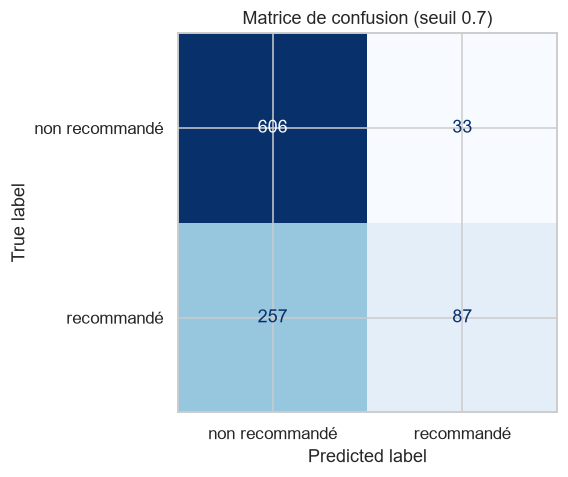

In [20]:
decision = (probabilites >= entrainement.SEUIL_RECOMMANDATION).astype(int)
technique.confusion(jeu["y"][jeu["i_test"]], decision, entrainement.SEUIL_RECOMMANDATION)
zones = entrainement.zones(jeu, probabilites)
zones.assign(taux_reel=lambda d: (100 * d["taux_reel"]).round(0))

La matrice de confusion est la vue standard des quatre cas possibles : on y lit directement les faux positifs, l'erreur la plus coûteuse pour un studio.

In [21]:
metier.nuage_erreurs(diagnostic, entrainement.SEUIL_RECOMMANDATION)

Un point par film, pour retrouver au survol les films mal classés : un graphique agrégé ne permet pas de dire lesquels.

### La probabilité annoncée suit-elle le ROI réel ?

Le modèle prédit une classe, rentable ou non. On vérifie ici qu'il ordonne aussi les films selon leur rentabilité réelle : chaque point est un film du test, placé selon la probabilité annoncée et le ROI qu'il a réellement obtenu.

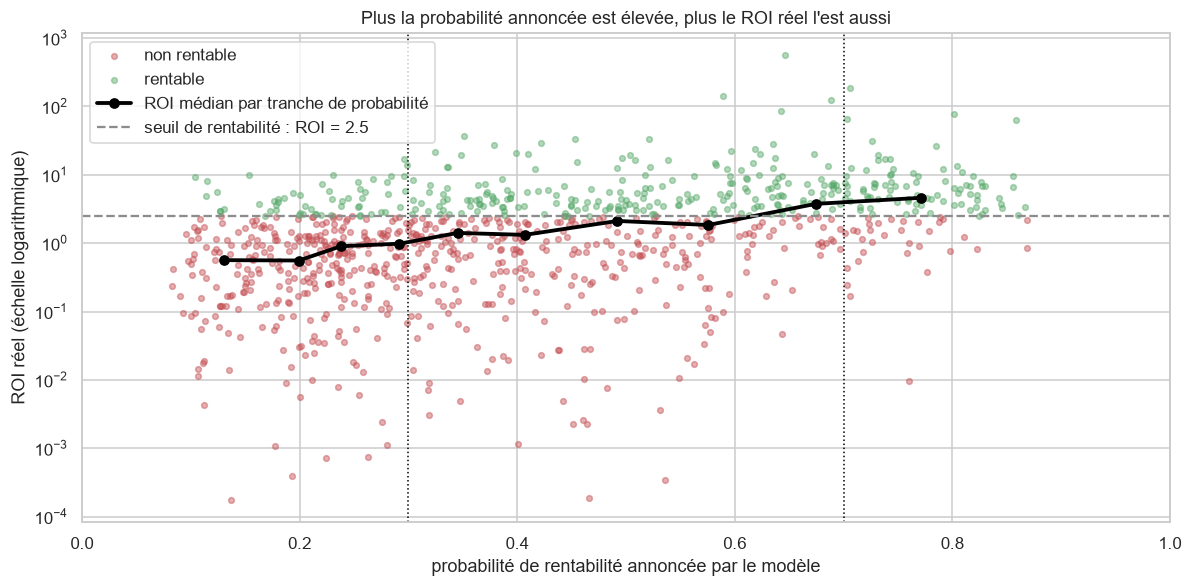

In [22]:
technique.probabilite_roi(diagnostic, seuil_rejet=entrainement.SEUIL_REJET,
                          seuil_recommandation=entrainement.SEUIL_RECOMMANDATION);

Un nuage de points, parce que l'on croise deux grandeurs continues film par film. L'axe du ROI est logarithmique car il s'étale de 0,0002 à 559 ; la ligne noire relie le ROI médian de dix tranches de probabilité, pour faire ressortir la tendance que le nuage seul laisse deviner.

**Le ROI réel monte avec la probabilité annoncée.** Le ROI médian passe de 0,6 pour les films les moins bien notés à 4,6 pour les mieux notés, soit huit fois plus.

| Zone | Films | ROI médian | Films à perte (ROI < 1) |
|---|---|---|---|
| Écarter (sous 0,3) | 360 | 0,7 | 61 % |
| Examiner (0,3 à 0,7) | 503 | 1,9 | 35 % |
| Recommander (au-dessus de 0,7) | 120 | 4,5 | 10 % |

**Le modèle n'a jamais vu le ROI** : il a appris un oui ou un non. Qu'il classe malgré tout les films dans l'ordre de leur rentabilité montre que la probabilité est un vrai indicateur de niveau, pas seulement une frontière.

**La dispersion reste forte** : à probabilité égale, les ROI s'étalent sur plusieurs ordres de grandeur. La probabilité indique une tendance sur un portefeuille de films, pas le résultat d'un film en particulier.

## 8. Contrôle méthodologique : le modèle a-t-il regardé la réponse ?

Avant d'interpréter un modèle, il faut prouver qu'il n'a pas regardé la réponse. On réentraîne le même modèle en lui ajoutant des variables connues seulement **après** la sortie.

,AUC
variables utilisées,
34 variables pré-production (réglages par défaut),0.746
+ nombre de votes et popularité,0.841
+ recettes,0.999


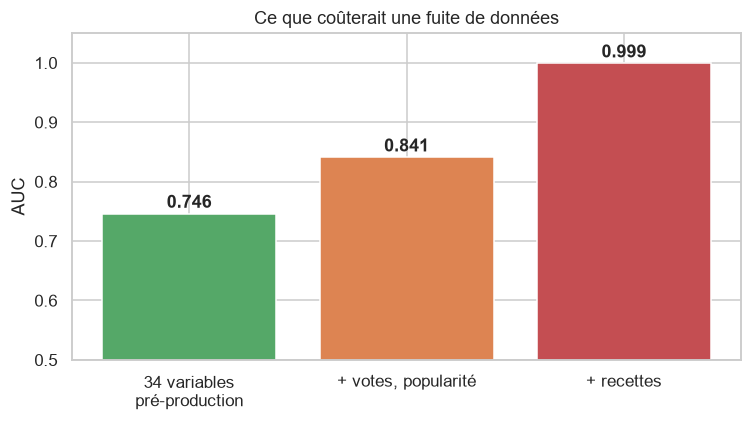

In [23]:
fuite = entrainement.controle_fuite(data, jeu)
technique.controle_fuite(fuite)
fuite.round(3)

Trois barres, parce que l'on compare trois scénarios distincts : l'écart de hauteur suffit à montrer ce qu'une fuite ferait gagner artificiellement.

Avec les recettes, l'AUC frôle 1 : le modèle recopie la réponse. Même le nombre de votes fait gagner près de 0,10, parce qu'un film très voté est presque toujours un film qui a marché. **C'est ce qui rend le score du modèle retenu crédible.** Ce contrôle utilise les réglages par défaut, d'où 0,746 et non 0,749.

## 9. Interprétabilité : quelles caractéristiques prédisent le succès ?

Les 5 variables les plus importantes :
  1. is_franchise (0.1251)
  2. log_budget (0.0504)
  3. cast_taux_hits_avant (0.0235)
  4. director_taux_hits_avant (0.0184)
  5. pays (0.0140)


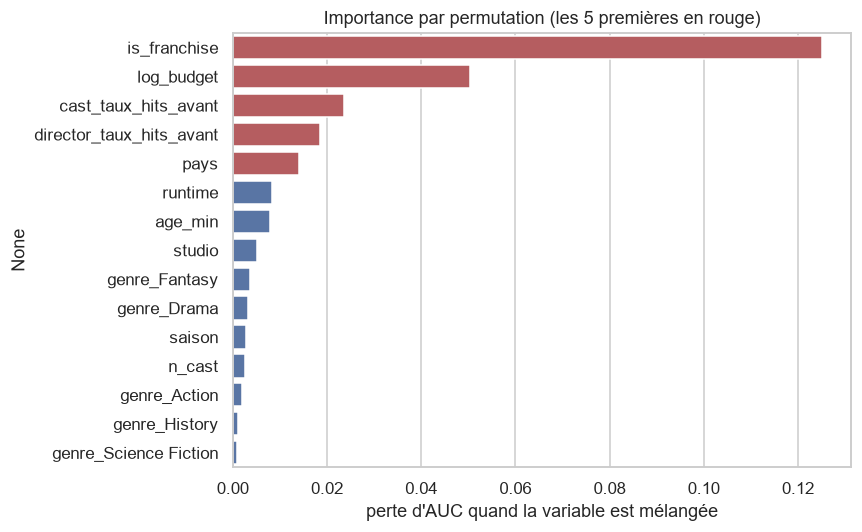

In [24]:
classement = entrainement.importance_variables(modele, jeu)
technique.importance(classement)
print("Les 5 variables les plus importantes :")
for rang, (nom, valeur) in enumerate(classement.head(5).items(), 1):
    print(f"  {rang}. {nom} ({valeur:.4f})")

Des barres horizontales triées : c'est un classement, et les noms de variables restent lisibles.

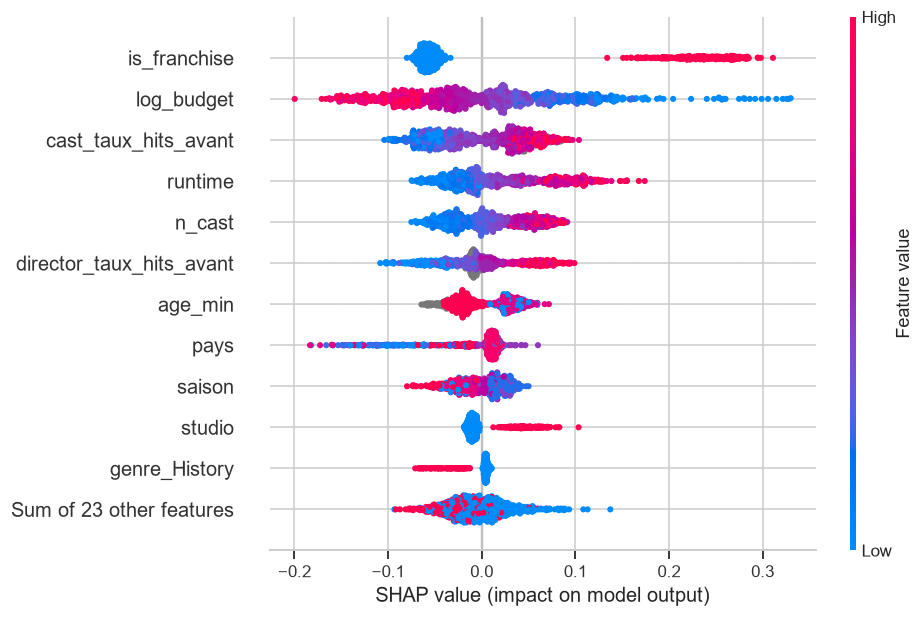

In [25]:
%matplotlib inline
import shap

explication = entrainement.explication_shap(modele, jeu)
shap.plots.beeswarm(explication, max_display=12, show=False);

Un point par film et par variable : la position donne le sens et la force de l'effet, la couleur la valeur de la variable. C'est le seul graphique qui montre le sens en plus de l'importance.

In [26]:
sens = entrainement.sens_des_effets(explication, jeu)
print(f"même sens d'effet dans les deux modèles : {int(sens['accord'].sum())} variables sur {len(sens)}")
sens.head(8).round(1)

même sens d'effet dans les deux modèles : 28 variables sur 29


,poids SHAP (points),sens gradient boosting,sens régression logistique,accord
variable,,,,
is_franchise,10.8,+,+,True
log_budget,6.9,-,-,True
cast_taux_hits_avant,4.3,+,+,True
runtime,4.0,+,+,True
n_cast,3.4,+,+,True
director_taux_hits_avant,3.1,+,+,True
age_min,2.8,-,-,True
genre_History,0.8,-,-,True


**Un seul modèle, deux lectures.** L'importance par permutation dit **combien** chaque variable compte : on la mélange, et on mesure l'AUC perdue. Les valeurs SHAP disent **dans quel sens** : pour chaque film, de combien de points chaque variable fait monter ou descendre la probabilité annoncée.

| Variable | Ce que le modèle en fait |
|---|---|
| **Saga** (le public connaît déjà l'univers) | l'effet le plus fort : environ +24 points de probabilité pour un film de saga, -6 pour un film isolé |
| **Budget** | à caractéristiques égales, plus le budget monte, plus la probabilité baisse : il faut d'autant plus de recettes pour atteindre 2,5 fois la mise |
| **Notoriété des têtes d'affiche et du réalisateur** | un taux de succès passé élevé augmente la probabilité |

**Le U de la section 2 s'explique ainsi** : la remontée des gros budgets ne vient pas du budget lui-même, mais du fait que les gros budgets sont souvent des sagas. C'est ce que le modèle sépare, et qu'un graphique à une seule variable mélange.

**Contrôle.** Le tableau ci-dessus compare le sens de chaque effet avec celui de la régression logistique du banc d'essai, modèle indépendant et plus simple : les deux s'accordent sur 28 variables sur 29, dont toutes celles qui pèsent. Les conclusions ne dépendent donc pas de l'algorithme retenu.

Les valeurs SHAP sont calculées par permutation, directement sur les probabilités du modèle : la somme des contributions d'un film redonne exactement sa probabilité.

## 10. Enregistrement du modèle retenu

In [27]:
%matplotlib inline
carte = persistance.sauvegarder(
    modele, variables, metriques=mesures, seuil=entrainement.SEUIL_RECOMMANDATION,
    description=("Rentabilité d'un film (ROI >= 2,5), variables pré-production, test temporel à partir de 2018. "
                 f"Recommander au-dessus de {entrainement.SEUIL_RECOMMANDATION}, "
                 f"écarter sous {entrainement.SEUIL_REJET}."))
{champ: carte[champ] for champ in ("cible", "modele", "seuil_decision", "metriques", "entraine_le")}

{'cible': 'is_hit',
 'modele': 'HistGradientBoostingClassifier',
 'seuil_decision': 0.7,
 'metriques': {'AUC': 0.749,
  'accuracy': 0.705,
  'precision': 0.725,
  'recall': 0.2529,
  'F1': 0.375,
  'Brier': 0.1909},
 'entraine_le': '2026-10-04T18:35:23+00:00'}

## 11. Ce qui a fait progresser le modèle

Le modèle n'a pas été obtenu du premier coup. Voici ce qui a été mis en place, et ce que chaque décision a apporté.

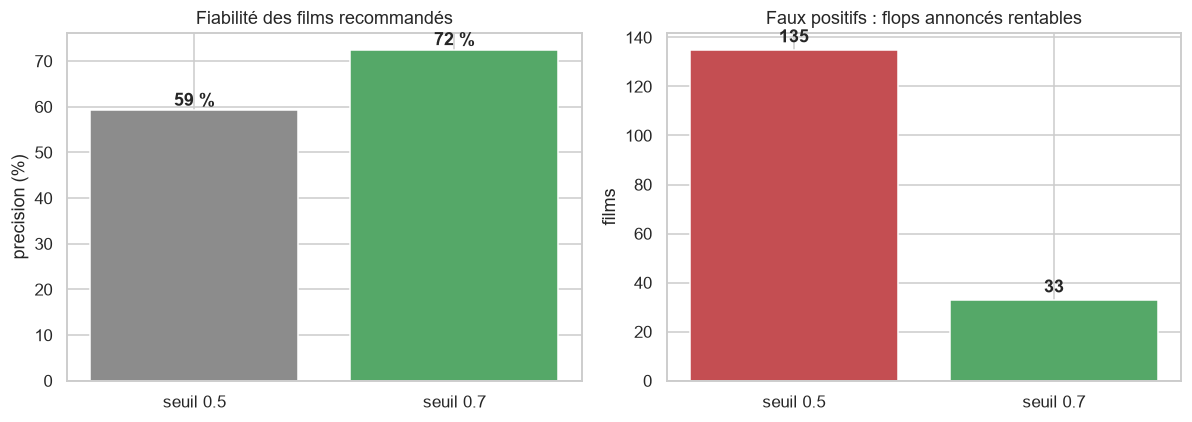

In [28]:
technique.gain_seuil(arbitrage);

Deux barres avant / après par indicateur : la comparaison ne porte que sur deux seuils.

| Ce qui a été mis en place | Effet |
|---|---|
| **Notoriété calculée sur les films antérieurs** plutôt que la popularité actuelle | supprime une fuite temporelle invisible |
| **Dollars constants 2023** pour budget et recettes | rend comparables des films de 1985 et de 2020 |
| **Année consolidée par vote des trois sources** | corrige 1 449 films du catalogue, dont 266 dans le jeu du modèle ; 6 changeaient de côté entre entraînement et test |
| **Budgets et recettes nuls ou aberrants écartés** | évite des ROI absurdes dans la cible |
| **Réglage des hyperparamètres** (25 combinaisons) | gain marginal : la limite vient des données |
| **Seuil porté de 0,5 à 0,7** | precision **59 % → 72 %**, faux positifs **135 → 33** |
| **Zone d'abstention entre 0,3 et 0,7** | isole les 503 films où le modèle est le moins fiable |

**Et ce qui a été testé puis écarté**, parce qu'une amélioration se mesure avant de s'adopter :

| Piste | Résultat |
|---|---|
| Analyse en composantes principales | AUC 0,737 → 0,714 : dégradation |
| Régression du ROI à la place de la classification | R² 0,14 : inexploitable pour décider |
| Variables postérieures à la sortie | AUC 0,999 : fuite de données, modèle inutilisable |

**La piste la plus prometteuse n'a pas pu être suivie** : la courbe d'apprentissage montre que le volume de films n'est plus le facteur limitant. Ce qui manque, ce sont des variables absentes de nos sources — budget marketing, concurrence à la date de sortie, notoriété du scénario.

## 12. Fallait-il un modèle ?

L'objection est légitime : si la saga (le public connaît déjà l'univers) et le budget expliquent l'essentiel, une règle écrite à la main suffirait. On la teste donc, sur le même jeu de test que le modèle.

,films retenus,precision,ROI médian,part de films à perte (ROI < 1)
sélection,,,,
tout le catalogue,983,0.35,1.39,0.41
règle : budget supérieur à 100 M$,132,0.43,2.27,0.20
règle : toutes les sagas,278,0.60,3.30,0.19
modèle : probabilité au-dessus de 0.7,120,0.72,4.46,0.10


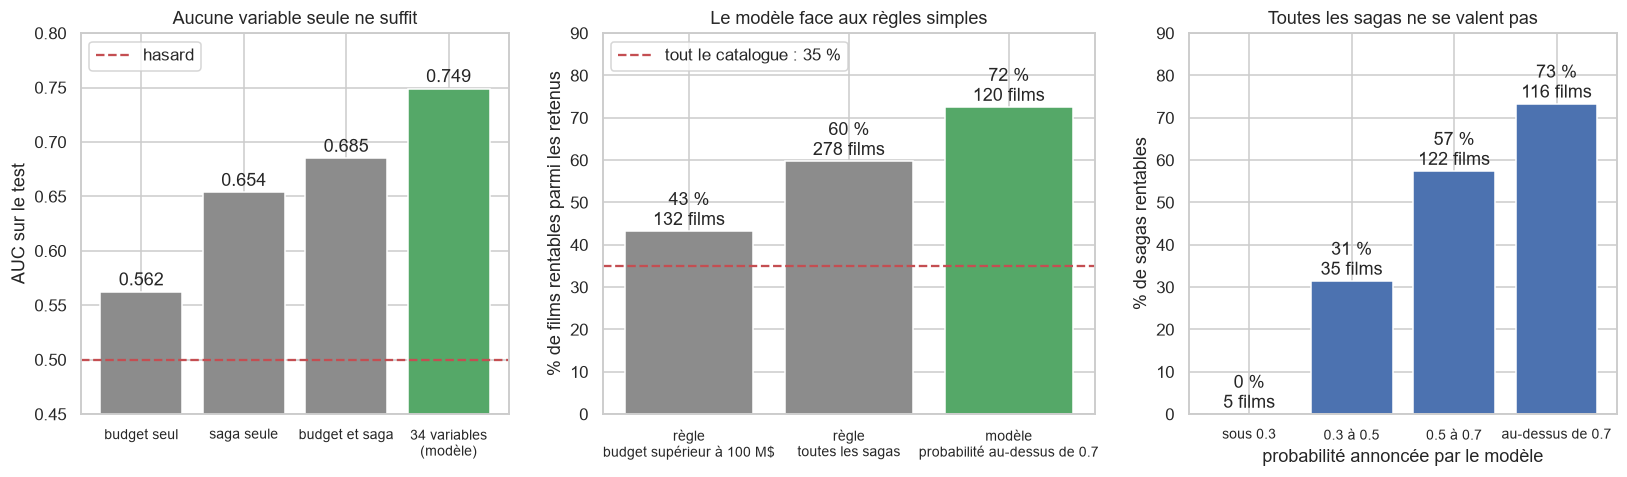

In [29]:
apport = entrainement.apport_modele(modele, data, jeu, probabilites)
technique.apport(apport)
apport["regles"].round(2)

Des barres, parce que l'on compare des stratégies distinctes. Les deux panneaux de droite partagent la même échelle pour que les pourcentages se comparent d'un coup d'œil.

## Conclusion : ce que le modèle apporte

### L'essentiel

On pourrait se passer de modèle et ne produire que des sagas (le public connaît déjà l'univers). Cette règle a été testée : **60 %** de films rentables. Le modèle en obtient **72 %**, avec deux fois moins de films à perte.

La différence vient de deux choses : il regarde 34 caractéristiques à la fois et non une seule, et il sait s'abstenir au lieu de trancher au hasard.

Il ne remplace pas le producteur : il lui indique où regarder en premier.

| Stratégie | Films rentables |
|---|---|
| Tout produire | 35 % |
| Ne produire que des sagas | 60 % |
| Suivre le modèle | **72 %** |

### Les éléments mesurés

**1. Aucune variable ne suffit seule.** Avec le budget seul, l'AUC est de 0,56, à peine mieux que le hasard. Avec la saga seule, 0,65. Avec les deux, 0,69. Le modèle complet atteint **0,75** : le reste vient de la notoriété, de la durée, du casting et du genre.

**2. Il trie là où la règle ne distingue rien.** « Produire toutes les sagas » retient 278 films, dont 60 % sont rentables. Le modèle en retient 120, dont **72 %** : la part de films à perte passe de 19 % à 10 %, le ROI médian de 3,3 à 4,5. À l'intérieur des sagas, il sépare celles qui réussissent à 73 % de celles qui réussissent à 31 % ; la règle leur donne la même réponse.

**3. Il donne une probabilité, pas un oui ou un non.** C'est ce qui permet de déplacer le seuil selon le coût d'une erreur, et de s'abstenir sur les 503 films où il ne sait pas. Une règle ne sait pas dire « je ne sais pas ». À l'autre bout, les 360 films qu'il écarte ne sont rentables qu'à 15 %.

**4. Sa performance est vérifiable.** AUC de 0,749 sur des films sortis après l'entraînement, contre 0,746 en validation croisée ; contrôle de fuite en section 8. Une règle d'expert ne se mesure pas ainsi avant d'être appliquée.

**Ce qu'il ne fait pas.** Sur les 120 films recommandés, 116 sont des sagas : le modèle **affine** la règle des sagas, il ne découvre pas de succès hors saga. La régression logistique obtient 0,747 sur le même test : le gain vient des variables construites, pas de la sophistication de l'algorithme. Restent les limites des données : seuls les films au budget public, un box-office brut et non un bénéfice, et la fermeture des salles en 2020-2021.

**En une phrase** : le budget et la saga donnent une intuition, le modèle en fait une probabilité chiffrée, vérifiée sur des films jamais vus, et qui divise par deux la part de films à perte par rapport à la règle « toutes les sagas ».

# Partie B — Recommander des films par groupes de spectateurs

**Question** : à quels spectateurs proposer quels films ?

**Démarche.** Chaque spectateur est décrit par les films qu'il a notés : une matrice spectateur × film, où une case vaut 1 si le film a été noté. Cette matrice est résumée en 50 dimensions par une décomposition en valeurs singulières (SVD), puis les spectateurs sont regroupés par k-means. Chaque groupe se voit proposer les films les mieux notés par ses membres, pondérés par le nombre de votes, puis ajustés aux genres préférés du spectateur.

**Données** : les 32 millions de notes MovieLens `ml-32m`, soit 200 948 spectateurs et 84 432 films. Cette partie est la plus lourde du notebook, en temps comme en mémoire.

| | Section | Contenu |
|---|---|---|
| 1 | Imports et paramètres | réglages de l'analyse |
| 2 | Chargement des données | notes et films MovieLens |
| 3 | Matrice utilisateur × film | qui a noté quoi |
| 4 | Réduction de dimension | 50 dimensions par spectateur |
| 5 | Choix du nombre de clusters | silhouette et stabilité |
| 6 | Clustering final | affectation des spectateurs |
| 7 | Profil de goûts des clusters | genres sur- et sous-consommés |
| 8 | Films de référence par cluster | films les mieux notés et films distinctifs |
| 9 | Recommandation pour un utilisateur | exemple complet |
| 10 | Évaluation | comparaison avec la popularité globale |
| 11 | Distance entre clusters | dendrogramme |
| 12 | Sauvegarde | modèle utilisé par le tableau de bord |

## 1. Imports et paramètres

In [30]:
import os
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.sparse import csr_matrix
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import normalize

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
BLEU, ROUGE, ENCRE = "#2a78d6", "#e34948", "#52514e"

In [31]:
DATA_DIR = os.path.join("..", "data", "processed")

_CANDIDATS = [os.environ.get("ML32M_DIR"), DATA_DIR, "data\\processed",
              os.path.join("..", "..", "data", "processed"), "ml-32m", "..\\ml-32m"]
DATA_DIR = next(
    (d for d in _CANDIDATS if d and os.path.exists(os.path.join(d, "ratings.parquet"))),
    DATA_DIR,
)

RATINGS_PATH = os.path.join(DATA_DIR, "ratings.parquet")
# movies.parquet (dans data/processed) a un schéma enrichi (box-office, TMDB/IMDb)
# sans la colonne "genres" nécessaire ici : les films MovieLens bruts sont donc
# dans movielens_movies.parquet, à part.
MOVIES_PATH = os.path.join(DATA_DIR, "movielens_movies.parquet")

SAMPLE_SIZE_USERS = None   # None = tous les utilisateurs ; sinon un entier, ex. 50_000

N_COMPONENTS = 50          # dimensions du vecteur "goûts" par utilisateur (sortie de la SVD)
N_CLUSTERS = 8          # valeur provisoire, recalculée en section 5
MIN_VOTES_IN_CLUSTER = 20  # lissage bayésien de la note d'un film dans un cluster
TOP_N_RECOMMENDATIONS = 10
SILHOUETTE_SAMPLE = 20_000

print(f"données lues depuis {DATA_DIR}")

données lues depuis ..\data\processed


## 2. Chargement des données

In [32]:
ratings = pd.read_parquet(RATINGS_PATH, columns=["userId", "movieId", "rating"])
ratings["userId"] = ratings["userId"].astype("int32")
ratings["movieId"] = ratings["movieId"].astype("int32")
ratings["rating"] = ratings["rating"].astype("float32")
movies = pd.read_parquet(MOVIES_PATH)

if SAMPLE_SIZE_USERS is not None:
    tires = (pd.Series(ratings["userId"].unique())
             .sample(n=SAMPLE_SIZE_USERS, random_state=RANDOM_STATE))
    ratings = ratings[ratings["userId"].isin(set(tires))]

print(f"Notes : {len(ratings):,} | Utilisateurs : {ratings['userId'].nunique():,} | "
      f"Films : {ratings['movieId'].nunique():,}")

Notes : 32,000,204 | Utilisateurs : 200,948 | Films : 84,432


## 3. Matrice utilisateur × film


In [33]:
user_ids = np.sort(ratings["userId"].unique())
movie_ids = np.sort(ratings["movieId"].unique())

user_to_idx = {u: i for i, u in enumerate(user_ids)}
movie_to_idx = {m: i for i, m in enumerate(movie_ids)}
idx_to_user = {i: u for u, i in user_to_idx.items()}

rows = ratings["userId"].map(user_to_idx).to_numpy()
cols = ratings["movieId"].map(movie_to_idx).to_numpy()
data = np.ones(len(ratings), dtype=np.float32)

user_item_matrix = csr_matrix((data, (rows, cols)), shape=(len(user_ids), len(movie_ids)))
n_ratings_per_user = np.asarray(user_item_matrix.sum(axis=1)).ravel()

print(f"Matrice utilisateur x film : {user_item_matrix.shape}, "
      f"densité = {user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1]):.4%}")

Matrice utilisateur x film : (200948, 84432), densité = 0.1886%


## 4. Réduction de dimension

In [34]:
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
user_embeddings = svd.fit_transform(user_item_matrix)
user_vectors = normalize(user_embeddings)

print(f"Variance expliquée cumulée ({N_COMPONENTS} composantes) : {svd.explained_variance_ratio_.sum():.2%}")
print(f"Forme des vecteurs utilisateurs : {user_vectors.shape}")
print(f"Poids relatif axe 1 / axe {N_COMPONENTS} : x{svd.singular_values_[0] / svd.singular_values_[-1]:.1f}")

correlation_activite = np.corrcoef(user_embeddings[:, 0], n_ratings_per_user)[0, 1]
print(f"Corrélation axe 1 / nombre de films notés : r = {correlation_activite:+.3f}")

Variance expliquée cumulée (50 composantes) : 34.71%
Forme des vecteurs utilisateurs : (200948, 50)
Poids relatif axe 1 / axe 50 : x13.1
Corrélation axe 1 / nombre de films notés : r = +0.863


## 5. Choix du nombre de clusters

> Deux critères sont nécessaires ici :
>
> - **la silhouette** répond à « existe-t-il des groupes séparés ? ». Elle va rester basse (~0,12) : il n'existe pas
>   de publics nettement séparés dans MovieLens, le goût est un continuum. Ce n'est pas un défaut du code,
>   c'est une propriété des données — viser une belle silhouette est un objectif inatteignable ici ;
> - **la stabilité** répond à « ce découpage est-il reproductible ? ». On apprend deux k-means sur deux
>   sous-échantillons disjoints et on mesure leur accord par l'ARI (1 = partitions identiques, 0 = hasard).
>   Un `k` dont le **pire** tirage s'effondre produit une partition qui dépend de l'échantillon : elle ne se
>   généralisera pas aux nouveaux utilisateurs, ce qui est rédhibitoire pour un recommandeur.
>
> `k` est donc choisi sur le **pire** ARI, pas sur la moyenne : un découpage qui s'effondre une fois sur trois n'est pas exploitable.

In [35]:
rng = np.random.default_rng(RANDOM_STATE)
silhouette_sample_idx = rng.choice(len(user_vectors), min(SILHOUETTE_SAMPLE, len(user_vectors)),
                                   replace=False)


def evaluate_k(X, k):
    labels = MiniBatchKMeans(k, random_state=RANDOM_STATE, batch_size=1024, n_init=10).fit_predict(X)
    return (silhouette_score(X[silhouette_sample_idx], labels[silhouette_sample_idx]),
            100 * np.bincount(labels, minlength=k).max() / len(X))


def cluster_stability(X, k, n_draws=3, size=40_000, seed=RANDOM_STATE):
    """Accord ARI entre deux k-means appris sur des sous-echantillons disjoints tires au sort."""
    alea = np.random.default_rng(seed)
    scores = []
    for _ in range(n_draws):
        a, b = (alea.choice(len(X), min(size, len(X)), replace=False) for _ in range(2))
        commun = np.intersect1d(a, b)
        ma = KMeans(k, n_init=5, random_state=alea.integers(1e6)).fit(X[a])
        mb = KMeans(k, n_init=5, random_state=alea.integers(1e6)).fit(X[b])
        scores.append(adjusted_rand_score(ma.predict(X[commun]), mb.predict(X[commun])))
    return np.mean(scores), np.min(scores)


k_range = [4, 5, 6, 7, 8, 9, 10, 15, 20, 30]
rows_k = []
for k in k_range:
    sil, biggest = evaluate_k(user_vectors, k)
    ari_mean, ari_min = cluster_stability(user_vectors, k)
    rows_k.append({"k": k, "silhouette": sil, "ari_moyen": ari_mean, "ari_min": ari_min,
                   "plus_gros_cluster_pct": biggest})
    print(f"k={k:>2} | silhouette={sil:+.4f} | ARI moyen={ari_mean:.3f} | pire ARI={ari_min:.3f}")

k_selection = pd.DataFrame(rows_k).set_index("k")
N_CLUSTERS = int(k_selection["ari_min"].idxmax())
print(f"\nk retenu (pire ARI le plus élevé) : {N_CLUSTERS}")
k_selection.round(3)

k= 4 | silhouette=+0.1080 | ARI moyen=0.850 | pire ARI=0.574


k= 5 | silhouette=+0.1051 | ARI moyen=0.975 | pire ARI=0.973


k= 6 | silhouette=+0.1187 | ARI moyen=0.851 | pire ARI=0.766


k= 7 | silhouette=+0.1193 | ARI moyen=0.919 | pire ARI=0.837


k= 8 | silhouette=+0.1246 | ARI moyen=0.934 | pire ARI=0.903


...

k=10 | silhouette=+0.1185 | ARI moyen=0.920 | pire ARI=0.901


k=15 | silhouette=+0.1120 | ARI moyen=0.842 | pire ARI=0.730


k=20 | silhouette=+0.0898 | ARI moyen=0.760 | pire ARI=0.626


k=30 | silhouette=+0.0861 | ARI moyen=0.706 | pire ARI=0.658

k retenu (pire ARI le plus élevé) : 5


,silhouette,ari_moyen,ari_min,plus_gros_cluster_pct
k,,,,
4,0.108,0.850,0.574,39.037
5,0.105,0.975,0.973,27.739
6,0.119,0.851,0.766,28.497
7,0.119,0.919,0.837,22.562
8,0.125,0.934,0.903,18.526
9,0.119,0.742,0.661,18.311
10,0.119,0.920,0.901,15.300
15,0.112,0.842,0.730,11.509
20,0.090,0.760,0.626,6.897


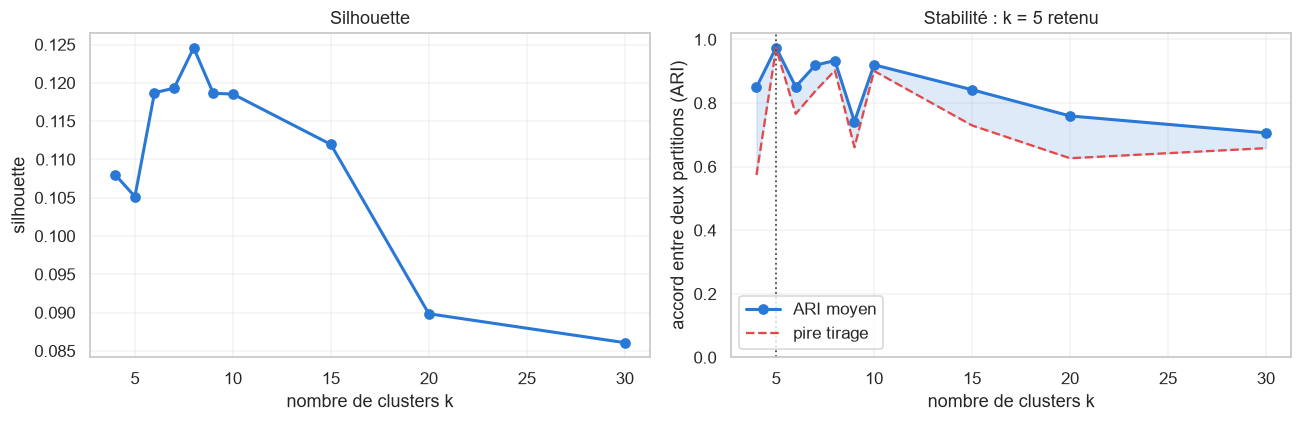

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_selection.index, k_selection["silhouette"], marker="o", color=BLEU, linewidth=2)
axes[0].set(xlabel="nombre de clusters k", ylabel="silhouette",
            title="Silhouette")

axes[1].fill_between(k_selection.index, k_selection["ari_min"], k_selection["ari_moyen"],
                     color=BLEU, alpha=0.15)
axes[1].plot(k_selection.index, k_selection["ari_moyen"], marker="o", color=BLEU, linewidth=2,
             label="ARI moyen")
axes[1].plot(k_selection.index, k_selection["ari_min"], linestyle="--", color=ROUGE, linewidth=1.5,
             label="pire tirage")
axes[1].axvline(N_CLUSTERS, color=ENCRE, linestyle=":", linewidth=1.2)
axes[1].set(xlabel="nombre de clusters k", ylabel="accord entre deux partitions (ARI)", ylim=(0, 1.02),
            title=f"Stabilité : k = {N_CLUSTERS} retenu")
axes[1].legend(loc="lower left")

for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()

## 6. Clustering final

In [37]:
kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, batch_size=1024, n_init=10
)
user_cluster_labels = kmeans.fit_predict(user_vectors)

user_clusters = pd.DataFrame(
    {"userId": [idx_to_user[i] for i in range(len(user_ids))], "cluster": user_cluster_labels}
)

print("Répartition des utilisateurs par cluster :")
user_clusters["cluster"].value_counts().sort_index()

Répartition des utilisateurs par cluster :


cluster
0    24579
1    33267
2    37889
3    49473
4    55740
Name: count, dtype: int64

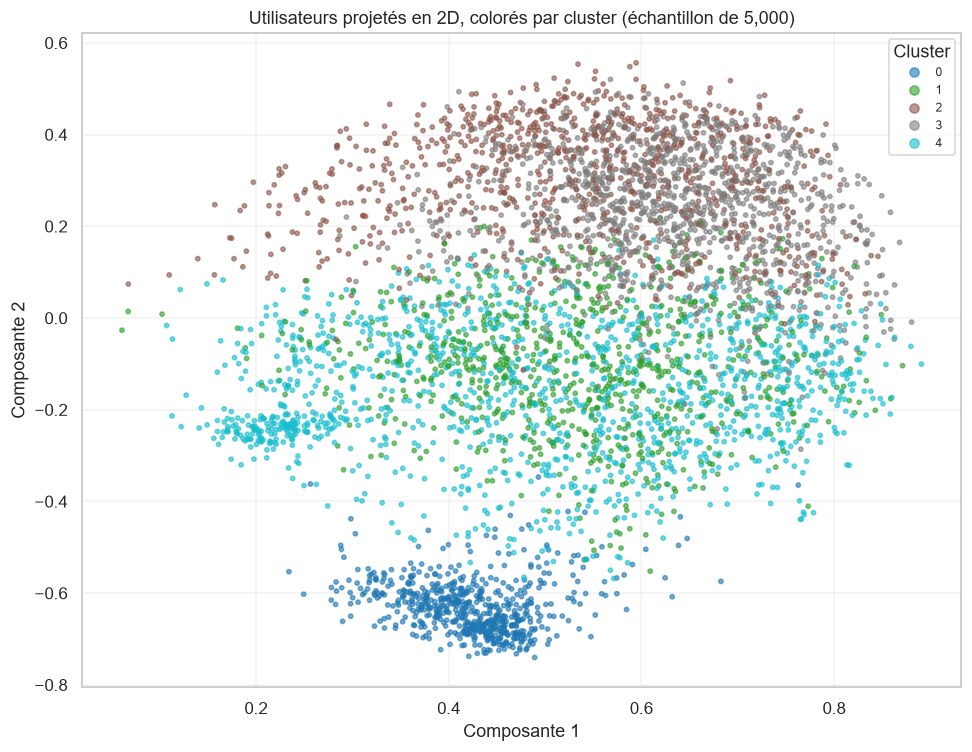

In [38]:
SCATTER_SAMPLE = 5_000  # nombre de points affichés (tout tracer serait illisible et lent)

rng_scatter = np.random.default_rng(RANDOM_STATE)
scatter_idx = rng_scatter.choice(len(user_vectors), min(SCATTER_SAMPLE, len(user_vectors)),
                                 replace=False)

# Projection 2D (uniquement pour la visu) d'un espace qui en a 50
coords_2d = TruncatedSVD(n_components=2, random_state=RANDOM_STATE).fit_transform(
    user_vectors[scatter_idx]
)
clusters_sample = user_cluster_labels[scatter_idx]

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    coords_2d[:, 0], coords_2d[:, 1],
    c=clusters_sample, cmap="tab10", s=8, alpha=0.6,
)
plt.title(f"Utilisateurs projetés en 2D, colorés par cluster (échantillon de {len(scatter_idx):,})")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.legend(*scatter.legend_elements(), title="Cluster", loc="best", fontsize=8)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 7. Profil de goûts des clusters


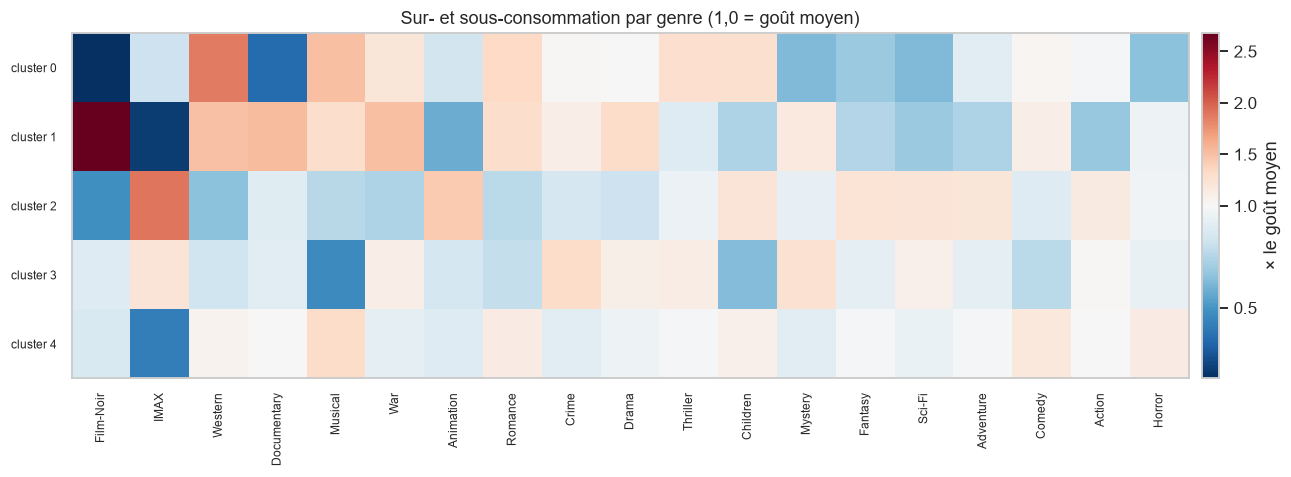

In [39]:
genre_pairs = movies.loc[movies["genres"].ne("(no genres listed)"), ["movieId", "genres"]].copy()
genre_pairs["genres"] = genre_pairs["genres"].str.split("|")
genre_pairs = genre_pairs.explode("genres").rename(columns={"genres": "genre"})
genre_pairs["genre"] = genre_pairs["genre"].astype("category")

liked = (ratings.loc[ratings["rating"] >= 4.0, ["userId", "movieId"]]
         .merge(user_clusters, on="userId").merge(genre_pairs, on="movieId"))
genre_volume = liked.groupby(["cluster", "genre"], observed=True).size().unstack("genre").fillna(0)
genre_share = genre_volume.div(genre_volume.sum(axis=1), axis=0)
overall_share = genre_volume.sum() / genre_volume.to_numpy().sum()
cluster_genre_profile = genre_share / overall_share

order = cluster_genre_profile.max().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(13, 0.42 * N_CLUSTERS + 2.4))
image = ax.imshow(cluster_genre_profile[order], aspect="auto", cmap="RdBu_r",
                  norm=TwoSlopeNorm(vcenter=1.0,
                                    vmin=cluster_genre_profile.to_numpy().min(),
                                    vmax=cluster_genre_profile.to_numpy().max()))
ax.set_xticks(range(len(order)), order, rotation=90, fontsize=8)
ax.set_yticks(range(len(cluster_genre_profile)),
              [f"cluster {i}" for i in cluster_genre_profile.index], fontsize=8)
ax.set_title("Sur- et sous-consommation par genre (1,0 = goût moyen)")
ax.grid(False)
fig.colorbar(image, ax=ax, pad=0.01, label="× le goût moyen")
plt.tight_layout()

## 8. Films de référence par cluster

In [40]:
def compute_cluster_top_movies(ratings_with_cluster, min_votes=MIN_VOTES_IN_CLUSTER):
    stats = (
        ratings_with_cluster.groupby(["cluster", "movieId"])["rating"]
        .agg(mean_rating="mean", n_votes="count")
        .reset_index()
    )
    cluster_global_mean = ratings_with_cluster.groupby("cluster")["rating"].mean().rename("cluster_mean")
    stats = stats.merge(cluster_global_mean, on="cluster")

    v, m, R, C = stats["n_votes"], min_votes, stats["mean_rating"], stats["cluster_mean"]
    stats["weighted_rating"] = (v / (v + m)) * R + (m / (v + m)) * C
    return stats


cluster_movie_stats = compute_cluster_top_movies(ratings.merge(user_clusters, on="userId"))
cluster_movie_stats = cluster_movie_stats.merge(movies[["movieId", "title", "genres"]], on="movieId")

cluster_movie_stats[cluster_movie_stats["cluster"] == 0].sort_values(
    "weighted_rating", ascending=False
).head(10)[["title", "genres", "mean_rating", "n_votes", "weighted_rating"]]

,title,genres,mean_rating,n_votes,weighted_rating
515,Schindler's List (1993),Drama|War,4.502428,10297,4.500578
310,"Shawshank Redemption, The (1994)",Crime|Drama,4.480975,15059,4.479738
693,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy,4.493201,809,4.470404
1100,Wallace & Gromit: The Wrong Trousers (1993),Animation|Children|Comedy|Crime,4.449296,355,4.401240
717,Wallace & Gromit: A Close Shave (1995),Animation|Children|Comedy,4.407100,662,4.381913
1143,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,4.324138,1015,4.309145
49,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,4.295309,9507,4.293740
828,"Godfather, The (1972)",Crime|Drama,4.300393,764,4.281205
575,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,4.269800,16162,4.268908
772,Lone Star (1996),Drama|Mystery|Western,4.281915,658,4.260273


In [41]:
global_movie_stats = compute_cluster_top_movies(ratings.assign(cluster=0))[["movieId", "weighted_rating"]]
global_movie_stats = global_movie_stats.rename(columns={"weighted_rating": "global_weighted"})
cluster_movie_stats = cluster_movie_stats.merge(global_movie_stats, on="movieId", how="left")
cluster_movie_stats["distinctive_score"] = (
    cluster_movie_stats["weighted_rating"] - cluster_movie_stats["global_weighted"]
)


def describe_clusters(top_genres=5, top_movies=5, min_votes=50):
    for cluster_id in sorted(user_clusters["cluster"].unique()):
        size = (user_clusters["cluster"] == cluster_id).sum()
        top_g = cluster_genre_profile.loc[cluster_id].sort_values(ascending=False).head(top_genres)
        top_m = (
            cluster_movie_stats[
                (cluster_movie_stats["cluster"] == cluster_id)
                & (cluster_movie_stats["n_votes"] >= min_votes)
            ]
            .sort_values("distinctive_score", ascending=False)
            .head(top_movies)
        )

        print(f"\n=== Cluster {cluster_id} ({size:,} utilisateurs, {100 * size / len(user_clusters):.1f} %) ===")
        print("Genres sur-consommés :", ", ".join(f"{g} (x{v:.2f})" for g, v in top_g.items()))
        print("Films distinctifs :")
        for _, row in top_m.iterrows():
            print(f"  - {row['title']} (+{row['distinctive_score']:.2f} vs global, {row['n_votes']} votes)")


describe_clusters()


=== Cluster 0 (24,579 utilisateurs, 12.2 %) ===
Genres sur-consommés : Western (x1.88), Musical (x1.51), Romance (x1.34), Thriller (x1.29), Children (x1.27)
Films distinctifs :
  - Stupids, The (1996) (+0.90 vs global, 220 votes)
  - Batman & Robin (1997) (+0.85 vs global, 92 votes)
  - In the Army Now (1994) (+0.78 vs global, 54 votes)
  - Street Fighter (1994) (+0.75 vs global, 64 votes)
  - Jaws 3-D (1983) (+0.69 vs global, 55 votes)

=== Cluster 1 (33,267 utilisateurs, 16.6 %) ===
Genres sur-consommés : Film-Noir (x2.68), Documentary (x1.53), War (x1.50), Western (x1.49), Drama (x1.31)
Films distinctifs :
  - Barney's Great Adventure (1998) (+0.54 vs global, 57 votes)
  - Big Top Pee-Wee (1988) (+0.53 vs global, 88 votes)
  - Babe: Pig in the City (1998) (+0.52 vs global, 1427 votes)
  - I Spit on Your Grave (Day of the Woman) (1978) (+0.49 vs global, 52 votes)
  - Pootie Tang (2001) (+0.49 vs global, 63 votes)

=== Cluster 2 (37,889 utilisateurs, 18.9 %) ===
Genres sur-consommés 

## 9. Recommandation pour un utilisateur

In [42]:
_counts = liked.groupby(["userId", "genre"], observed=True).size()
user_genre_share = _counts / _counts.groupby(level=0).transform("sum")
movie_genres_map = genre_pairs.astype({"genre": object}).groupby("movieId")["genre"].agg(list)


def get_user_genre_affinity(user_id):
    try:
        return user_genre_share.loc[user_id].to_dict()
    except KeyError:
        return {}


def recommend_for_user(user_id, n=TOP_N_RECOMMENDATIONS, affinity_weight=0.5):
    cluster_id = user_clusters.loc[user_clusters["userId"] == user_id, "cluster"]
    if cluster_id.empty:
        raise ValueError(f"Utilisateur {user_id} inconnu.")
    cluster_id = cluster_id.iloc[0]

    already_rated = set(ratings.loc[ratings["userId"] == user_id, "movieId"])
    affinity = get_user_genre_affinity(user_id)

    candidates = cluster_movie_stats[
        (cluster_movie_stats["cluster"] == cluster_id)
        & (~cluster_movie_stats["movieId"].isin(already_rated))
        & (cluster_movie_stats["n_votes"] >= MIN_VOTES_IN_CLUSTER)
    ].copy()

    candidates["genre_affinity"] = [
        sum(affinity.get(g, 0.0) for g in movie_genres_map.get(m, []))
        for m in candidates["movieId"]
    ]
    candidates["final_score"] = candidates["weighted_rating"] * (
        1 + affinity_weight * candidates["genre_affinity"]
    )

    return (candidates.sort_values("final_score", ascending=False).head(n)
            [["movieId", "title", "genres", "weighted_rating", "genre_affinity", "final_score", "n_votes"]]
            .reset_index(drop=True))


example_user_id = int(ratings["userId"].iloc[0])
cluster_exemple = user_clusters.set_index("userId").loc[example_user_id, "cluster"]
print(f"Recommandations pour l'utilisateur {example_user_id} (cluster {cluster_exemple}) :")
recommend_for_user(example_user_id)

Recommandations pour l'utilisateur 1 (cluster 1) :


,movieId,title,genres,weighted_rating,genre_affinity,final_score,n_votes
0,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,4.247259,0.584211,5.487905,4240
1,3307,City Lights (1931),Comedy|Drama|Romance,4.239141,0.584211,5.477417,1631
2,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.242428,0.578947,5.470500,17139
3,3462,Modern Times (1936),Comedy|Drama|Romance,4.212671,0.584211,5.443214,2081
4,1244,Manhattan (1979),Comedy|Drama|Romance,4.159688,0.584211,5.374755,5618
5,1224,Henry V (1989),Action|Drama|Romance|War,4.168500,0.573684,5.364201,2792
6,2019,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama,4.351164,0.463158,5.358802,6055
7,903,Vertigo (1958),Drama|Mystery|Romance|Thriller,4.252290,0.515789,5.348933,8418
8,6016,City of God (Cidade de Deus) (2002),Action|Adventure|Crime|Drama|Thriller,4.169304,0.563158,5.343292,3136
9,858,"Godfather, The (1972)",Crime|Drama,4.481826,0.384211,5.342808,17817


## 10. Évaluation

In [43]:
K_EVAL, RATING_THRESHOLD, N_EVAL_USERS = 10, 4.0, 2000

shuffled = np.random.default_rng(RANDOM_STATE).permutation(len(ratings))
cut = int(0.8 * len(ratings))
train_ratings = ratings.iloc[shuffled[:cut]]
test_ratings = ratings.iloc[shuffled[cut:]]

train_users = np.sort(train_ratings["userId"].unique())
train_movies = np.sort(train_ratings["movieId"].unique())
train_matrix = csr_matrix(
    (np.ones(len(train_ratings), dtype=np.float32),
     (train_ratings["userId"].map({u: i for i, u in enumerate(train_users)}).to_numpy(),
      train_ratings["movieId"].map({m: i for i, m in enumerate(train_movies)}).to_numpy())),
    shape=(len(train_users), len(train_movies)))

train_vectors = normalize(TruncatedSVD(N_COMPONENTS, random_state=RANDOM_STATE).fit_transform(train_matrix))
train_labels = MiniBatchKMeans(N_CLUSTERS, random_state=RANDOM_STATE, batch_size=1024,
                               n_init=10).fit_predict(train_vectors)
cluster_of = pd.Series(train_labels, index=train_users)
print(f"Clustering réappris sur le train seul : {len(train_users):,} utilisateurs, k={N_CLUSTERS}")

Clustering réappris sur le train seul : 200,948 utilisateurs, k=5


In [44]:
def bayesian_ranking(block, reference_mean, m=MIN_VOTES_IN_CLUSTER):
    """Classement des films d'un bloc par note pondere bayesienne."""
    stats = block.groupby("movieId")["rating"].agg(["mean", "count"])
    v = stats["count"]
    return ((v / (v + m)) * stats["mean"] + (m / (v + m)) * reference_mean).sort_values(ascending=False)


train_with_cluster = train_ratings.assign(cluster=train_ratings["userId"].map(cluster_of))
cluster_rankings = {c: bayesian_ranking(block, block["rating"].mean())
                    for c, block in train_with_cluster.groupby("cluster")}
global_ranking = bayesian_ranking(train_ratings, train_ratings["rating"].mean())

seen_in_train = train_ratings.groupby("userId")["movieId"].agg(set)
liked_in_test = test_ratings[test_ratings["rating"] >= RATING_THRESHOLD].groupby("userId")["movieId"].agg(set)
eligible = [u for u in liked_in_test.index if u in cluster_of.index and u in seen_in_train.index]
eval_users = pd.Series(eligible).sample(min(N_EVAL_USERS, len(eligible)), random_state=RANDOM_STATE)


def precision_at_k(user_id, ranking, k=K_EVAL):
    """Part des k films recommandes que l'utilisateur a reellement aimes dans le test."""
    seen = seen_in_train.loc[user_id]
    recommended = [m for m in ranking.index if m not in seen][:k]
    return len(set(recommended) & liked_in_test.loc[user_id]) / k


scores = pd.DataFrame({
    "par cluster": [precision_at_k(u, cluster_rankings[cluster_of.loc[u]]) for u in eval_users],
    "popularité globale": [precision_at_k(u, global_ranking) for u in eval_users],
})

summary = pd.DataFrame({
    "precision@10": scores.mean(),
    "ic_95_bas": scores.mean() - 1.96 * scores.sem(),
    "ic_95_haut": scores.mean() + 1.96 * scores.sem(),
})
ecart = scores["par cluster"] - scores["popularité globale"]
print(f"{len(eval_users):,} utilisateurs évalués, vivier de candidats identique pour les deux méthodes")
print(f"écart moyen : {ecart.mean():+.4f} (IC 95 % : {ecart.mean() - 1.96 * ecart.sem():+.4f} "
      f"à {ecart.mean() + 1.96 * ecart.sem():+.4f})")
summary.round(4)

2,000 utilisateurs évalués, vivier de candidats identique pour les deux méthodes
écart moyen : +0.0218 (IC 95 % : +0.0185 à +0.0251)


,precision@10,ic_95_bas,ic_95_haut
par cluster,0.0469,0.0430,0.0508
popularité globale,0.0251,0.0227,0.0275


L'écart entre les deux méthodes se lit avec son intervalle de confiance. **L'intervalle de l'écart ne contient pas zéro** : sur ce protocole, recommander par cluster fait mieux que recommander les films les plus populaires à tout le monde. Si l'intervalle avait contenu zéro, l'apport du clustering n'aurait pas été démontré.

Une limite subsiste, commune aux deux méthodes : le découpage entre entraînement et test est **aléatoire**, donc on prédit en partie du passé avec du futur. Pour un recommandeur, un découpage **temporel** (entraîner sur les notes antérieures à une date, tester sur les suivantes) est plus proche de l'usage réel : c'est le protocole retenu dans la partie A, et la principale amélioration à apporter ici.

## 11. Distance entre clusters

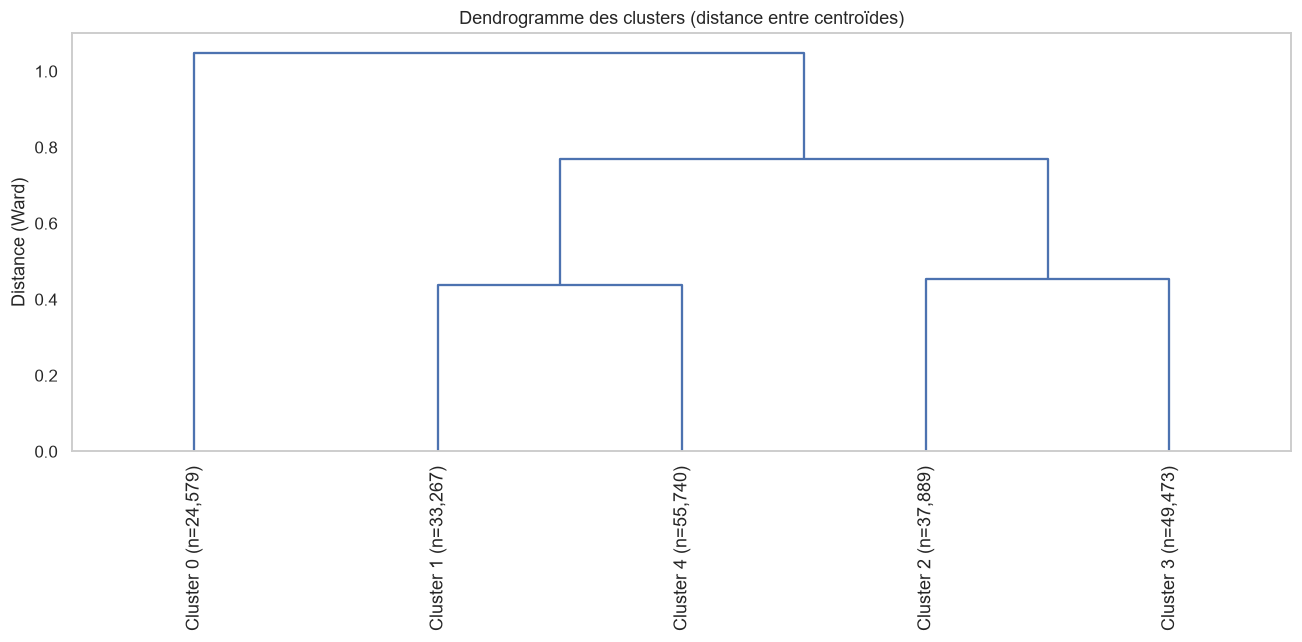

In [45]:
cluster_sizes = user_clusters["cluster"].value_counts().sort_index()
dendro_labels = [f"Cluster {i} (n={cluster_sizes.get(i, 0):,})" for i in range(N_CLUSTERS)]

Z = linkage(kmeans.cluster_centers_, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=dendro_labels, leaf_rotation=90, color_threshold=0)
plt.title("Dendrogramme des clusters (distance entre centroïdes)")
plt.ylabel("Distance (Ward)")
plt.grid(False)
plt.tight_layout()
plt.show()

## 12. Sauvegarde

In [46]:
os.makedirs("models", exist_ok=True)
with open("models/clustering_recommender.pkl", "wb") as f:
    pickle.dump(
        {
            "svd": svd,
            "kmeans": kmeans,
            "n_clusters": N_CLUSTERS,
            "normalisation": "L2 sur la sortie SVD (pas de StandardScaler)",
            "matrice": "binaire vu / pas vu",
            "user_to_idx": user_to_idx,
            "movie_to_idx": movie_to_idx,
            "user_clusters": user_clusters,
            "cluster_movie_stats": cluster_movie_stats,
            "cluster_genre_profile": cluster_genre_profile,
        },
        f,
    )

print("Modèle sauvegardé dans models/clustering_recommender.pkl")

Modèle sauvegardé dans models/clustering_recommender.pkl
